# v13 caveat

**These scores are not used in leaderboards.** Captioning failures during indexing (empty-caption DLQ force-inserts and abandoned items) left collections incomplete or degraded and inflated retrieval scores. v14 is the first comparable Milvus dual-index / CLIP DFN run after those failures were addressed.


# Libraries

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
# Add benchmarking dir so helpers.plot is importable
_bench = Path.cwd().parents[3]
sys.path.insert(0, str(_bench))
from helpers.plot import (
    plot_grouped_bar_by_columns,
    plot_single_bar_metric,
    plot_rank_comparison,
    plot_multi_rank_comparison,
    render_dlq_analysis,
)


# Evaluating SageBench

This notebook summarizes raw query-level metrics from a **Sagebench** benchmark run. The labeled pairs and queries come from **[SageBench](https://huggingface.co/datasets/sagecontinuum/SageBench)** on Hugging Face (**2.4k rows** per the Hub). Retrieval used a [CLIP](https://huggingface.co/apple/DFN5B-CLIP-ViT-H-14-378) checkpoint **`DFN5B-CLIP-ViT-H-14-378`** (DFN-trained), [NRP](https://nrp.ai/documentation/userdocs/ai/llm-managed/#available-models) **[gemma-4-31B-it](https://huggingface.co/google/gemma-4-31B-it)** for captions, and **response_limit=25** (up to 25 images per query), aligned with production.

To better understand the results, each image is matched with a query in the dataset. Although not all matched images are relevant to the query.

This version tested the image search with `DFN5B-CLIP-ViT-H-14-378` and `NRP's gemma-4-31B-it` on **Milvus** (replacing Weaviate), using dual dense indexes plus BM25 and CLIP rerank. It included:

- **gemma-4-31B-it for Caption Generation**: Captions are generated for images using NRP's gemma-4-31B-it model.
- **Dual-index Vector Search**: Image and caption CLIP embeddings are stored as separate Milvus fields (`image_vector`, `caption_vector`) instead of a single fused vector. At query time, dense similarity blends both legs with `clip_alpha` (default 0.7 → 70% image / 30% caption).
- **Keyword Search (BM25)**: Milvus BM25 over `search_text` (captions and related text), replacing Weaviate keyword search.
- **Hybrid Search**: Dense (dual CLIP) + sparse (BM25) retrieval via Milvus `WeightedRanker`, controlled by `query_alpha` (default 0.4 → 40% dense / 60% keyword). Query method: `clip_hybrid_query_dual_index`.
- **CLIP Reranker (`DFN5B-CLIP-ViT-H-14-378`)**: Replaces the previous Weaviate / [ms-marco-MiniLM-L6-v2](https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2) reranker. The query text is embedded once and scored against stored `image_vector`s (no per-hit image I/O), matching production `logits_per_image`-style ranking.
- **Triton Dynamic Batching**: CLIP (and Gemma when served on Triton) use server-side dynamic batching so concurrent embedding/caption requests are coalesced into larger GPU batches, improving indexing and query throughput versus one-request-per-inference.

Here were the Hyperparameters used for the image search:

In [2]:
#show config values
df = pd.read_csv('config_values.csv')
df

,Config Variable,Value,Type
0,DATASET_DEFAULT,sagecontinuum/SageBench,str
1,advanced_query_parameters,"{'query_alpha': 0.4, 'clip_alpha': 0.7, 'enabl...",dict
2,caption_model_name,gemma,str
3,caption_model_prompt,\nrole:\nYou are a world-class Scientific Imag...,str
4,embed_caption,True,bool
5,embed_image,True,bool
6,enable_bm25,True,bool
7,enable_caption_generation,True,bool
8,hnsw_dist_metric,VectorDistances.COSINE,VectorDistances
9,hnsw_dynamicEfMax,500,int


## Query and image collection process

The following follows the **[SageBench dataset card](https://huggingface.co/datasets/sagecontinuum/SageBench)** so metrics below are easier to interpret.

### Query collection

Queries in SageBench are **natural-language descriptions** of **Sage Continuum** sensor imagery, aimed at how researchers would search when **both visuals and node metadata** matter. They are **model-generated** (e.g. OpenAI **GPT-5-mini** in the published pipeline).

**Process (see [SageBench](https://huggingface.co/datasets/sagecontinuum/SageBench)):**

1. **Seed images** — `query_plan_num_seeds` controls how many seeds are drawn from the candidate pool.
2. **Query generation** — For each seed, the model produces a query that a user might type to find that scene; prompts require **at least one** reference to Sage fields (**vsn**, **zone**, **host**, **job**, **plugin**, **camera**, **project**, **address**) plus visual content (example style: *“Animal … from vsn V001, job imagesampler-bottom-1 (core zone)”*).
3. **One query per seed** — Each query gets a **`query_id`** (e.g. `query_001`) and drives candidate retrieval and labeling.

Full pipeline options and costs are documented on the Hub and in **`config_values.csv`** (and `summary/` in the dataset repo).


### Image annotation

SageBench combines **per-image vision outputs**, **per-pair relevance labels**, and an offline **CLIP** score—see the [dataset card](https://huggingface.co/datasets/sagecontinuum/SageBench).

**1. Vision annotation (per image)** — OpenAI vision (**GPT-5-mini**) in the published pipeline:

- **summary** — Short factual caption (≤30 words).
- **Taxonomy** — `viewpoint`, `lighting`, `environment_type`, `sky_condition` (allowed values are fixed in the benchmaker config).
- **Boolean scene flags** — `horizon_present`, `ground_present`, `sky_dominates`, `vegetation_present`, `water_present`, `buildings_present`, `vehicle_present`, `person_present`, `animal_present`, `night_scene`, `precipitation_visible`, `multiple_objects`.
- **tags** — Controlled vocabulary (roughly 12–18 tags per image).
- **confidence** — Dict of scores (e.g. for taxonomy dimensions) in `[0, 1]`.

**Sage metadata** (per image, for retrieval and analysis): **vsn**, **zone**, **host**, **job**, **plugin**, **camera**, **project**, **address** — `project` and `address` are resolved via the Sage manifest API in the dataset build ([card](https://huggingface.co/datasets/sagecontinuum/SageBench)).

**2. Relevance labeling (per query–image pair)** — An **AI judge** (GPT-5-mini) assigns **relevance_label** ∈ {0, 1}, following **metadata-aware** criteria: both whether the **query’s metadata constraints** match the candidate image and whether the **visual content** fits.

**3. CLIPScore** — Precomputed text–image similarity as **clip_score** using **`apple/DFN5B-CLIP-ViT-H-14-378`** (same family as this benchmark’s CLIP backbone).

Hyperparameter tables: **`summary/config_values.csv`** in this results folder and on the Hub.


### Query Categories

SageBench does **not** use a single categorical “topic” per query. Instead, each row carries **Sage metadata**, **scene taxonomy**, and **tags**, so you can slice metrics by node, camera, environment, etc. (aligned with the [Hub schema](https://huggingface.co/datasets/sagecontinuum/SageBench)).

**Sage metadata (strings)** — `vsn`, `zone`, `host`, `job`, `plugin`, `camera`, `project`, `address`

**Scene taxonomy (strings)** — `viewpoint` (e.g. `ground_horizontal`, `fisheye_sky`, `duo_view`), `lighting` (e.g. `day`, `night`, `dusk`, `overcast_light`), `environment_type` (e.g. `vegetation`, `sky_dominant`, `ground_dominant`, `mixed`, `urban`, `rural`), `sky_condition` (e.g. `clear`, `partly_cloudy`, `overcast`, `fog_or_haze`)

**Boolean scene flags** — Same list as in vision annotation (`horizon_present` … `multiple_objects`).

Queries are written so retrieval must handle **metadata-in-the-text** (node id, job name, zone, camera, address snippets, …) **and** visual cues—see the dataset card for curation rationale and limitations (e.g. binary relevance, generator coverage).


### Data Split
The dataset only has a train split. Users can split the dataset as they see fit.

## Query Coverage

Queries cover a range of topics and taxonomies:

![Image Sample](https://huggingface.co/datasets/sagecontinuum/SageBench/resolve/main/summary/random_image_sample.png)
![Query Coverage](https://huggingface.co/datasets/sagecontinuum/SageBench/resolve/main/summary/image_proportion_donuts.png)


## Exploratory data analysis

The SageBench repo on the Hub includes a notebook with charts and tables over the published split.

**[SageBench EDA (Hub)](https://huggingface.co/datasets/sagecontinuum/SageBench/blob/main/summary/SageBench_eda_analysis.ipynb)**

Use it alongside the metrics below to relate aggregate scores to metadata and taxonomy distributions.

## Query metric dataset

Each row summarizes **one query** from **[SageBench](https://huggingface.co/datasets/sagecontinuum/SageBench)** (`query_text` / `query_id` on the Hub) and how the search system performed on it.

### Columns in `query_eval_metrics.csv` (one row per query)

- **query_id**: Matches **`query_id`** in SageBench (e.g. `query_001`).
- **query** (source column **`query_text`**): Text sent to retrieval; must be metadata-aware per the [dataset card](https://huggingface.co/datasets/sagecontinuum/SageBench).
- **total_images**: Total images returned for that query (up to **response_limit**).
- **correctly_returned**: Count of returned images whose paired query in the dataset matches the query used in search.
- **incorrectly_returned**: Count of returned images whose paired query in the dataset does not match the query used in search.
- **relevant_images**: Count of returned images labeled relevant to the query in the dataset.
- **non_relevant_images**: Count of returned images labeled non-relevant to the query in the dataset.
- **accuracy**: Share of returned images that are “correctly returned” vs **total_images**.
- **precision**: Share of returned images that are relevant vs **total_images**.
- **recall**: Share of relevant items in the dataset that appear in the returned top-k (see benchmark code for the exact denominator).
- **hit**: `1` if at least one relevant image appears in the top-k; mean over queries = hit rate @ k (**k** = **response_limit**).
- **NDCG** (from `rerank_score_NDCG`): Ranking quality using the **reranker** scores; higher means relevant items rank higher.
- **clip_NDCG** (from `clip_score_NDCG`): Same as NDCG but using **CLIP** scores from the dataset for comparison.
- **rr** (from `rerank_score_reciprocal_rank`): Reciprocal rank of the first relevant item using reranker scores; mean = MRR.
- **clip_rr** (from `clip_score_reciprocal_rank`): Reciprocal rank using CLIP scores for comparison.
- **diversity**: Diversity of the top-k list (1 − intra-list similarity of retrieved vectors); higher = less redundant results.
- **vsn (Sage metadata)**: The vsn (node identifier) that took the original image the query was generated from.
- **zone (Sage metadata)**: The zone (compute zone in the node) that took the original image the query was generated from.
- **host (Sage metadata)**: The host (compute host in the node) that took the original image the query was generated from.
- **job (Sage metadata)**: The job (job identifier) that took the original image the query was generated from.
- **plugin (Sage metadata)**: The plugin (plugin identifier) that took the original image the query was generated from.
- **camera (Sage metadata)**: The camera (camera identifier) that took the original image the query was generated from.
- **project (Sage metadata)**: The project (project identifier) that took the original image the query was generated from.
- **address (Sage metadata)**: The address (the node address location) that took the original image the query was generated from.
- **viewpoint**: The viewpoint of the original image the query was generated from.
- **lighting**: The lighting of the original image the query was generated from.
- **environment_type**: The environment type of the original image the query was generated from.
- **sky_condition**: The sky condition of the original image the query was generated from.
- **horizon_present**: Whether the horizon is present in the seed image associated with the query.
- **ground_present**: Whether the ground is present in that seed image.
- **sky_dominates**: Whether the sky dominates the frame (**`sky_dominates`** on the Hub).
- **vegetation_present**: Whether vegetation is present in that seed image.
- **water_present**: Whether water is present in the original image the query was generated from.
- **buildings_present**: Whether buildings are present in the original image the query was generated from.
- **vehicle_present**: Whether a vehicle is present in the original image the query was generated from.
- **person_present**: Whether a person is present in the original image the query was generated from.
- **animal_present**: Whether an animal is present in the original image the query was generated from.
- **night_scene**: Whether it is night time in the original image the query was generated from.
- **precipitation_visible**: Whether precipitation is visible in the original image the query was generated from.
- **multiple_objects**: Whether multiple salient objects appear in the original image the query was generated from.


In [3]:
#load in metric data
df = pd.read_csv('query_eval_metrics.csv')

#rename ndcg and reciprocal rank columns
df = df.rename(columns={
    'rerank_score_NDCG': 'NDCG',
    'clip_score_NDCG': 'clip_NDCG',
    'rerank_score_reciprocal_rank': 'rr',
    'clip_score_reciprocal_rank': 'clip_rr'
})
df

,query_id,query,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,...,sky_dominates,vegetation_present,water_present,buildings_present,vehicle_present,person_present,animal_present,night_scene,precipitation_visible,multiple_objects
0,query_001,Wet paved industrial yard with puddles and an ...,25,1,24,1,24,0.04,0.04,1.0,...,False,False,True,True,True,False,False,False,False,True
1,query_007,night infrared close-up of a metal railing wit...,25,1,24,1,24,0.04,0.04,1.0,...,False,True,False,False,False,False,False,True,False,True
2,query_008,sunny grassy field with dirt road and bright s...,25,1,24,1,24,0.04,0.04,1.0,...,True,True,False,False,False,False,False,False,False,True
3,query_004,pond with dock and small house from vsn W083 (...,25,1,24,1,24,0.04,0.04,1.0,...,False,True,True,True,False,False,False,False,False,True
4,query_005,nighttime dark scene with silhouetted vegetati...,25,0,25,0,25,0.00,0.00,0.0,...,False,True,False,False,False,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,query_118,fisheye sky view with sun and scattered clouds...,25,0,25,0,25,0.00,0.00,0.0,...,True,False,False,True,False,False,False,False,False,True
116,query_120,daytime parking lot with parked cars from vsn ...,25,1,24,1,24,0.04,0.04,1.0,...,False,True,False,True,True,False,False,False,False,True
117,query_119,Snow-covered valley with cabins and fences in ...,25,1,24,1,24,0.04,0.04,1.0,...,True,True,False,True,False,False,False,False,True,True
118,query_116,fisheye all-sky daytime image from top_camera ...,25,0,25,0,25,0.00,0.00,0.0,...,True,False,False,True,False,False,False,False,False,True


## Indexing DLQ Summary

First, we will look at the DLQ to get an understanding of failed items.

During indexing, failed items are held in a dead-letter queue (`dlq_records.csv`), retried with exponential backoff, then recorded with a terminal status.

CSV columns: `image_id`, `query_id`, `reason`, `error`, `attempts`, `final_status`, `last_error`.

| `final_status` | Meaning |
|----------------|---------|
| `retried_ok` | A later retry succeeded with a real LLM caption |
| `inserted_degraded` | Soft caption failure exhausted retries; item was **force-inserted** using the dataset `summary` as caption backup (or `""` if none) |
| `abandoned` | Hard failure (or force-insert failed); item was **not** indexed |

`reason` is typically `caption_failed` (empty LLM caption) or `hard_fail` (CLIP / processing errors). Use the tables below to see how often fallback was used versus full abandon.

In [4]:
render_dlq_analysis(Path("."))


DLQ rows: 896  |  unique image_ids: 714 | unique query_ids: 120

Rundown:
  force-insert, fallback used (inserted_degraded): 896
  recovered on retry (retried_ok): 0
  never indexed (abandoned): 0
  attempts — mean=6.0, max=6


,final_status,count
0,inserted_degraded,896


,reason,count
0,caption_failed,896


,reason,final_status,count
0,caption_failed,inserted_degraded,896



Failures by query_id (soft=caption_failed, hard=other):


,query_id,soft,hard,total
83,query_084,13,0,13
12,query_013,11,0,11
22,query_023,11,0,11
28,query_029,11,0,11
39,query_040,11,0,11
...,...,...,...,...
86,query_087,4,0,4
92,query_093,4,0,4
30,query_031,3,0,3
31,query_032,3,0,3


## Overall Metrics
Now, we will begin with evaluating all queries.

In [5]:
#calculate the average/sum of each metric
total_images = df['total_images'].sum()
correctly_returned = df['correctly_returned'].sum()
incorrectly_returned = df['incorrectly_returned'].sum()
relevant_images = df['relevant_images'].sum()
non_relevant_images = df['non_relevant_images'].sum()
accuracy = df['accuracy'].mean()
precision = df['precision'].mean()
recall = df['recall'].mean()
hit_rate = df['hit'].mean()
ndcg = df['NDCG'].mean()
clip_ndcg = df['clip_NDCG'].mean()
mrr = df['rr'].mean()
clip_mrr = df['clip_rr'].mean()
diversity = df['diversity'].mean()

# Summary of key metrics
overall_metrics = {
    'total_images': total_images,
    'correctly_returned': correctly_returned,
    'incorrectly_returned': incorrectly_returned,
    'relevant_images': relevant_images,
    'non_relevant_images': non_relevant_images,
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'hit_rate': hit_rate,
    'NDCG': ndcg,
    'clip_NDCG': clip_ndcg,
    'mrr': mrr,
    'clip_mrr': clip_mrr,
    'diversity': diversity
}

# Print the summary
for key, value in overall_metrics.items():
    print(f"{key}: {value}")

# Insights
print("\nInsights:")
print(f"The system returned a total of {correctly_returned} correct images out of {total_images} total images returned.")
print(f"The accuracy of the system is {accuracy:.4f}, indicating that {accuracy*100:.2f}% of the returned images correctly matched with the query.")
print(f"The precision of the system is {precision:.4f}, indicating that {precision*100:.2f}% of the total images returned were relevant images.")
print(f"The recall of the system is {recall:.4f}, indicating that {recall*100:.2f}% of the total relevant images in the dataset were returned.")
print(f"The hit rate of the system is {hit_rate:.4f}, indicating that {hit_rate*100:.2f}% of the total queries processed had at least one relevant image.")
print(f"The NDCG score is {ndcg:.4f}, and the Clip NDCG score is {clip_ndcg:.4f}, indicating the ranking quality of the returned images against the CLIP DFN5B-CLIP-ViT-H-14-378 model.")
print(f"The MRR score is {mrr:.4f}, and the Clip MRR score is {clip_mrr:.4f}, indicating how early the first relevant result appears.")
print(f"The diversity of the system is {diversity:.4f} (on a 0–1 scale), indicating the \"spread\" of the returned images. A lower score means the results are more redundant (i.e., highly similar to each other), while a higher score indicates more varied results.")

total_images: 3000
correctly_returned: 103
incorrectly_returned: 2897
relevant_images: 79
non_relevant_images: 2921
accuracy: 0.034333333333333334
precision: 0.026333333333333334
recall: 0.5599999999999999
hit_rate: 0.6166666666666667
NDCG: 0.2956538253654983
clip_NDCG: 0.46351995528031387
mrr: 0.2068490413024082
clip_mrr: 0.41458694083694086
diversity: 0.22223651134775296

Insights:
The system returned a total of 103 correct images out of 3000 total images returned.
The accuracy of the system is 0.0343, indicating that 3.43% of the returned images correctly matched with the query.
The precision of the system is 0.0263, indicating that 2.63% of the total images returned were relevant images.
The recall of the system is 0.5600, indicating that 56.00% of the total relevant images in the dataset were returned.
The hit rate of the system is 0.6167, indicating that 61.67% of the total queries processed had at least one relevant image.
The NDCG score is 0.2957, and the Clip NDCG score is 0.4

## Metrics based on Environment Type

Now, we will evaluate queries based on their environment type.


In [6]:
# Group by environment type and calculate the sum/mean of each metric
environment_metrics = df.groupby('environment_type').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

#rename columns
environment_metrics = environment_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

environment_metrics

,environment_type,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,ground_dominant,300,8,292,3,297,0.026667,0.010000,0.250000,0.250000,0.116132,0.113446,0.100160,0.069444,0.147038
1,mixed,800,29,771,26,774,0.036250,0.032500,0.683333,0.781250,0.381626,0.611228,0.273018,0.554167,0.204209
2,other,100,4,96,3,97,0.040000,0.030000,0.750000,0.750000,0.311856,0.657732,0.180556,0.625000,0.230343
3,rural,75,5,70,3,72,0.066667,0.040000,1.000000,1.000000,0.595628,0.876977,0.472222,0.833333,0.301832
4,sky_dominant,875,28,847,20,855,0.032000,0.022857,0.457143,0.514286,0.240157,0.369592,0.155942,0.323810,0.235050
5,unknown,75,3,72,2,73,0.040000,0.026667,0.666667,0.666667,0.168038,0.426314,0.046970,0.363636,0.319879
6,urban,25,1,24,1,24,0.040000,0.040000,1.000000,1.000000,0.356207,0.630930,0.166667,0.500000,0.375774
7,vegetation,750,25,725,21,729,0.033333,0.028000,0.577778,0.633333,0.319090,0.486477,0.232632,0.441984,0.232674


### Accuracy

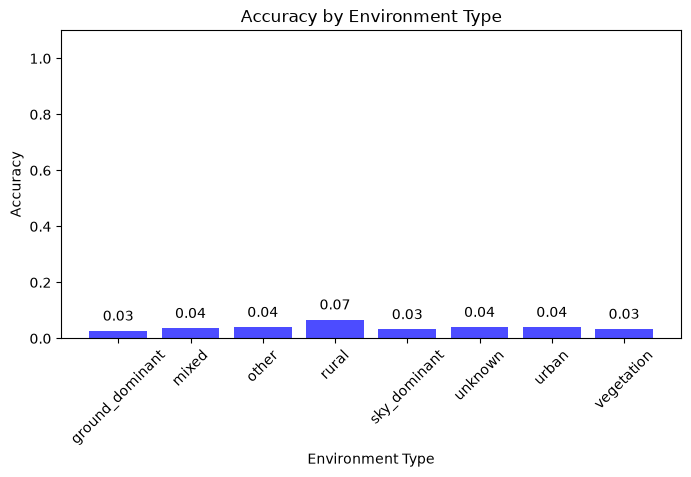

In [7]:
plot_single_bar_metric(environment_metrics, x_column='environment_type', metric='accuracy', title='Accuracy by Environment Type', ylabel='Accuracy', xlabel='Environment Type')

### Precision

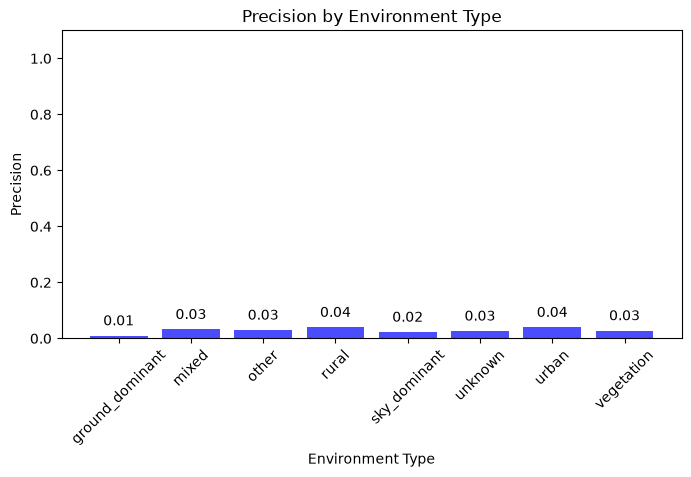

In [8]:
plot_single_bar_metric(environment_metrics, x_column='environment_type', metric='precision', title='Precision by Environment Type', ylabel='Precision', xlabel='Environment Type')

### Recall

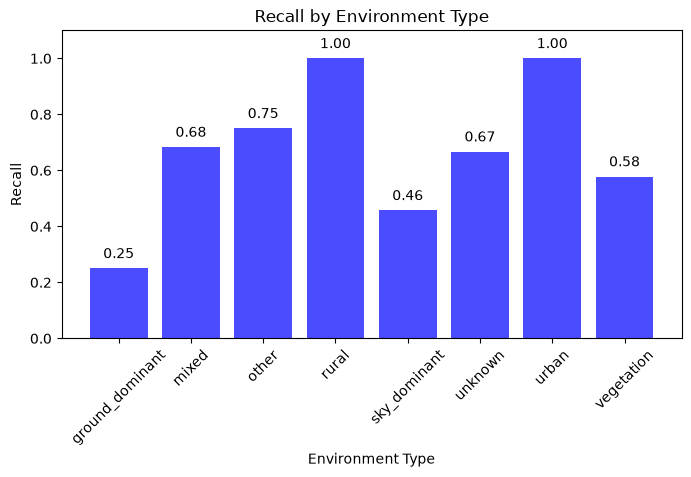

In [9]:
plot_single_bar_metric(environment_metrics, x_column='environment_type', metric='recall', title='Recall by Environment Type', ylabel='Recall', xlabel='Environment Type')

### Hit Rate

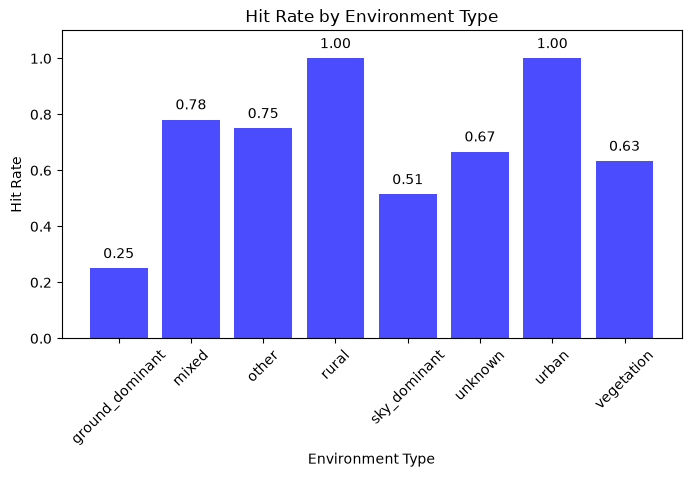

In [10]:
plot_single_bar_metric(environment_metrics, x_column='environment_type', metric='hit_rate', title='Hit Rate by Environment Type', ylabel='Hit Rate', xlabel='Environment Type')

### Diversity


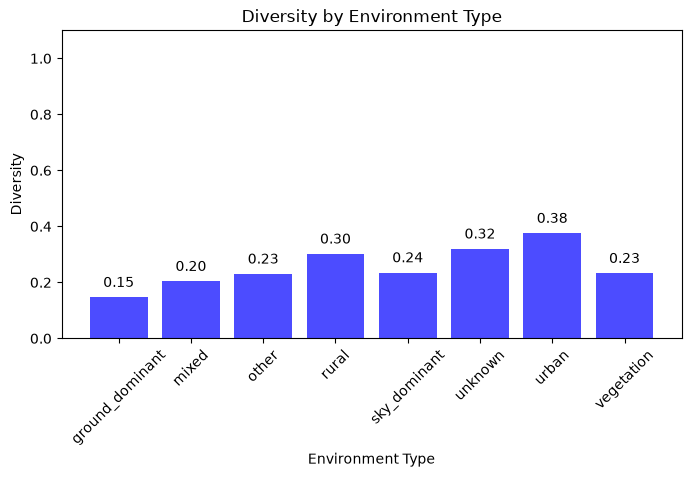

In [11]:
plot_single_bar_metric(environment_metrics, x_column='environment_type', metric='diversity', title='Diversity by Environment Type', ylabel='Diversity', xlabel='Environment Type')

### NDCG

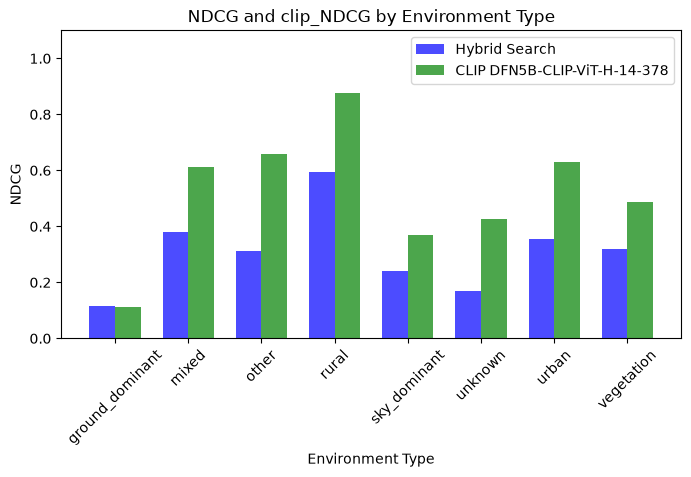

In [12]:
plot_rank_comparison(environment_metrics, x_column='environment_type', title='NDCG and clip_NDCG by Environment Type', xlabel='Environment Type')

### MRR

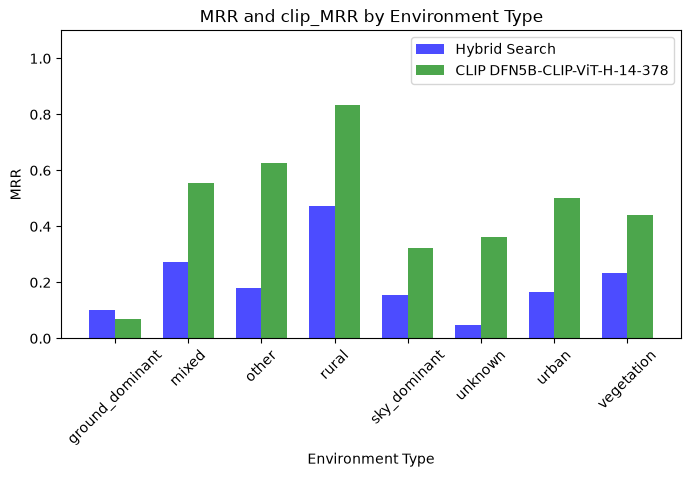

In [13]:
plot_rank_comparison(environment_metrics, x_column='environment_type', title='MRR and clip_MRR by Environment Type', xlabel='Environment Type', metric="MRR")

## Metrics based on Lighting

In [14]:


# Group by iconic_group and calculate the sum/mean of each metric
lighting_metrics = df.groupby(['lighting']).agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

#rename columns
lighting_metrics = lighting_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

lighting_metrics

,lighting,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,day,1625,58,1567,48,1577,0.035692,0.029538,0.602564,0.676923,0.337826,0.543670,0.237411,0.500513,0.210337
1,dusk,75,2,73,2,73,0.026667,0.026667,0.233333,0.666667,0.310226,0.543643,0.194444,0.500000,0.177480
2,night,1025,31,994,19,1006,0.030244,0.018537,0.447154,0.463415,0.186689,0.292855,0.115105,0.237583,0.240974
3,overcast_light,225,9,216,8,217,0.040000,0.035556,0.777778,0.777778,0.461558,0.557213,0.412500,0.497354,0.247562
4,unknown,50,3,47,2,48,0.060000,0.040000,1.000000,1.000000,0.390402,0.815465,0.187500,0.750000,0.178005


In [15]:
# Bar width
bar_width = 0.35
x = np.arange(len(lighting_metrics['lighting']))

### Accuracy

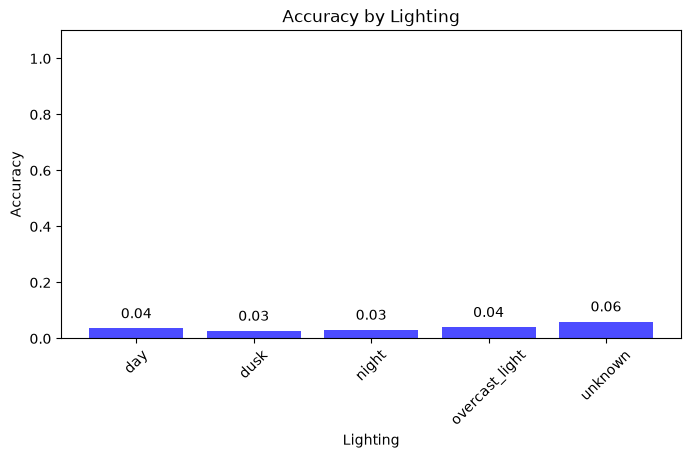

In [16]:
plot_single_bar_metric(lighting_metrics, x_column='lighting', metric='accuracy', title='Accuracy by Lighting', ylabel='Accuracy', xlabel='Lighting')

### Precision

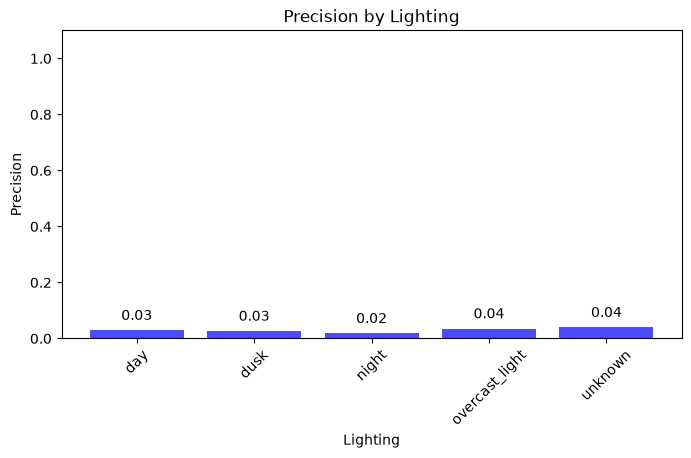

In [17]:
plot_single_bar_metric(lighting_metrics, x_column='lighting', metric='precision', title='Precision by Lighting', ylabel='Precision', xlabel='Lighting')

### Recall

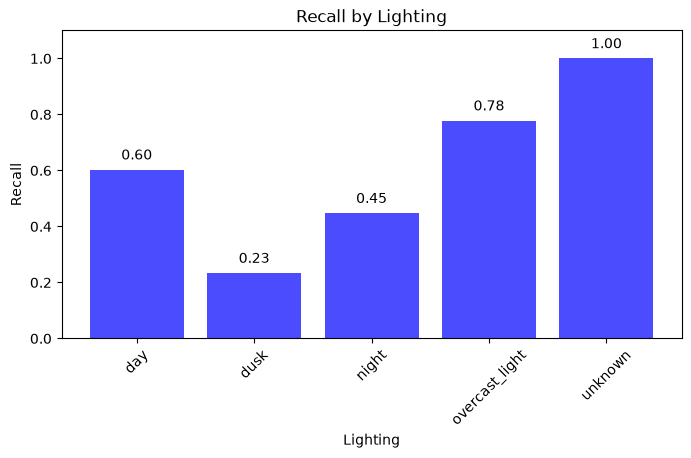

In [18]:
plot_single_bar_metric(lighting_metrics, x_column='lighting', metric='recall', title='Recall by Lighting', ylabel='Recall', xlabel='Lighting')

### Hit Rate

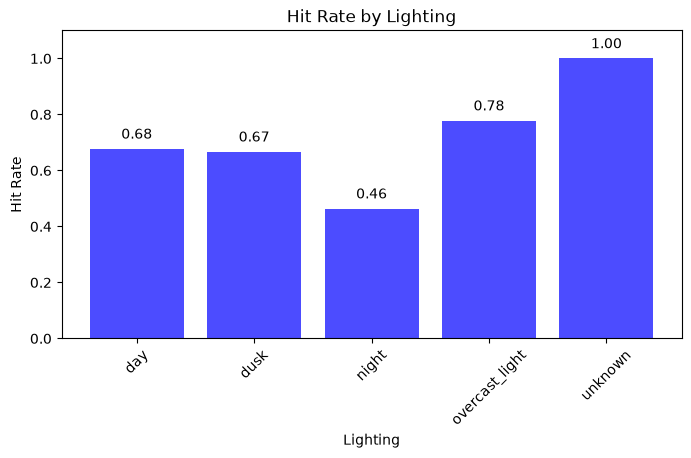

In [19]:
plot_single_bar_metric(lighting_metrics, x_column='lighting', metric='hit_rate', title='Hit Rate by Lighting', ylabel='Hit Rate', xlabel='Lighting')

### Diversity

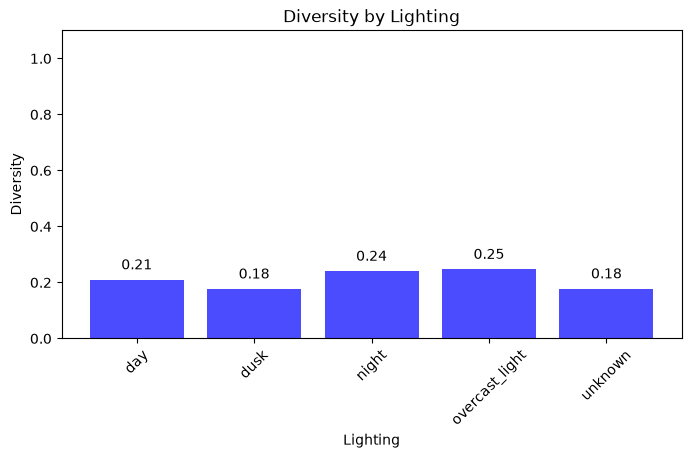

In [20]:
plot_single_bar_metric(lighting_metrics, x_column='lighting', metric='diversity', title='Diversity by Lighting', ylabel='Diversity', xlabel='Lighting')

### NDCG

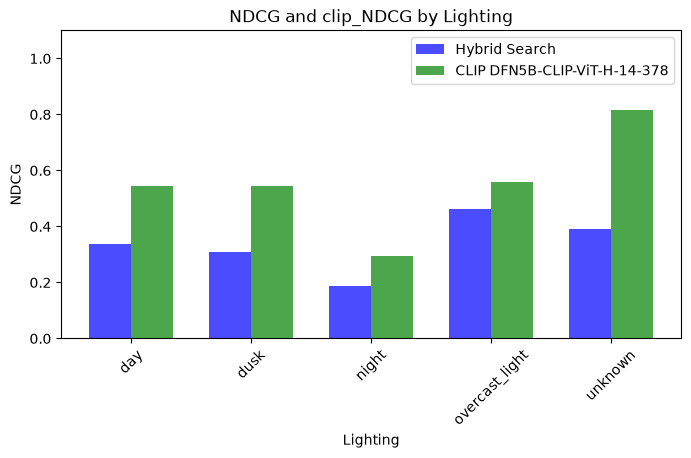

In [21]:
plot_rank_comparison(lighting_metrics, x_column='lighting', title='NDCG and clip_NDCG by Lighting', xlabel='Lighting')

### MRR

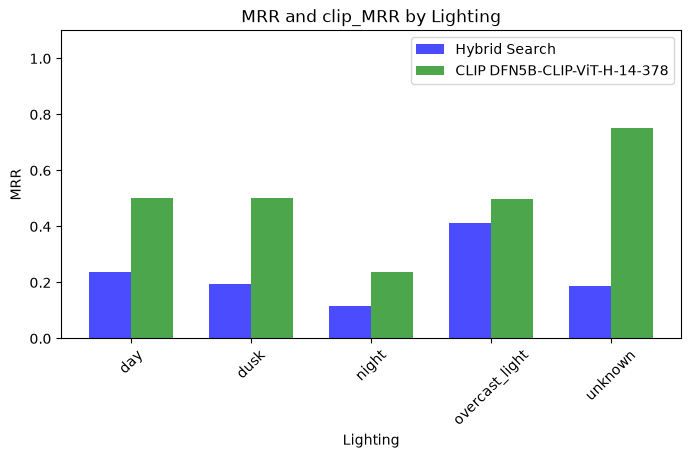

In [22]:
plot_rank_comparison(lighting_metrics, x_column='lighting', title='MRR and clip_MRR by Lighting', xlabel='Lighting', metric="MRR")

## Metrics based on Viewpoint

In [23]:
# Group by viewpoint and calculate the sum/mean of each metric
viewpoint_metrics = df.groupby('viewpoint').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

#rename columns
viewpoint_metrics = viewpoint_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

viewpoint_metrics

,viewpoint,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,duo_view,50,1,49,0,50,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.202919
1,fisheye_sky,700,22,678,17,683,0.031429,0.024286,0.464286,0.535714,0.240496,0.416924,0.154762,0.380952,0.216707
2,ground_horizontal,1925,68,1857,53,1872,0.035325,0.027532,0.610823,0.662338,0.315482,0.490608,0.224898,0.434972,0.222300
3,ground_upward,150,6,144,3,147,0.040000,0.020000,0.500000,0.500000,0.350755,0.315465,0.266667,0.250000,0.311334
4,oblique,125,5,120,5,120,0.040000,0.040000,0.633333,0.800000,0.423678,0.800000,0.304286,0.800000,0.116795
5,unknown,50,1,49,1,49,0.020000,0.020000,0.500000,0.500000,0.114762,0.139471,0.025000,0.045455,0.312851


### Accuracy

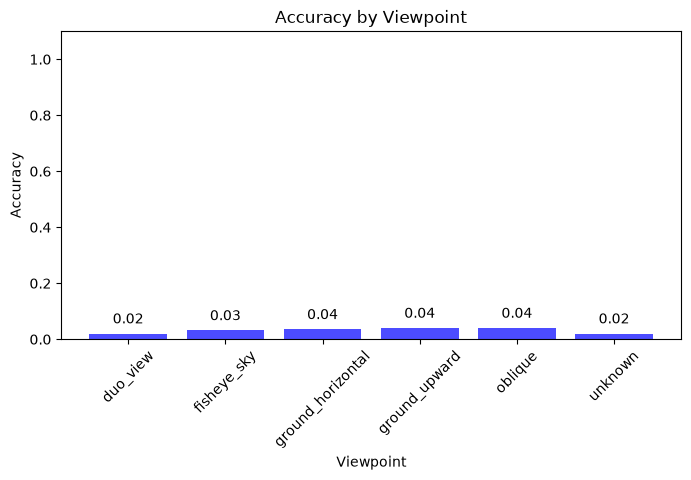

In [24]:
plot_single_bar_metric(viewpoint_metrics, x_column='viewpoint', metric='accuracy', title='Accuracy by Viewpoint', ylabel='Accuracy', xlabel='Viewpoint')

### Precision

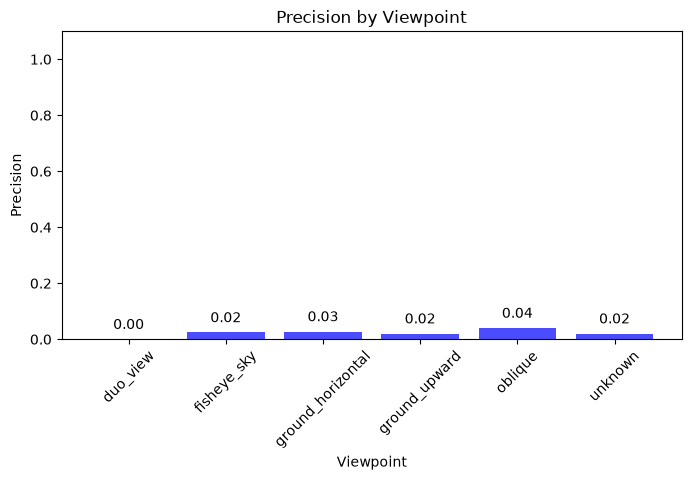

In [25]:
plot_single_bar_metric(viewpoint_metrics, x_column='viewpoint', metric='precision', title='Precision by Viewpoint', ylabel='Precision', xlabel='Viewpoint')

### Recall

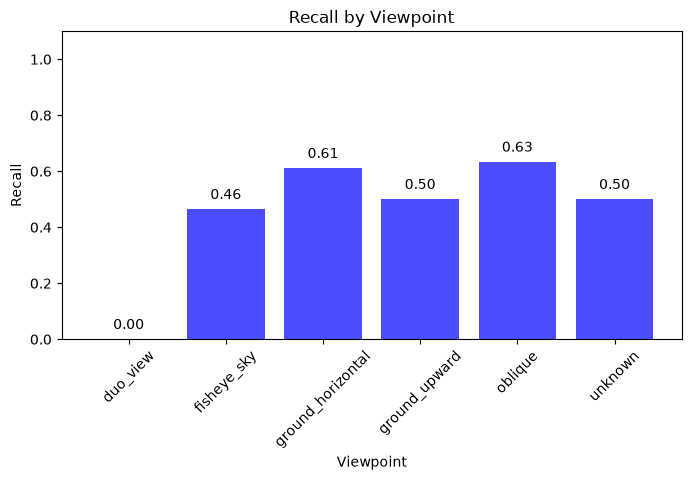

In [26]:
plot_single_bar_metric(viewpoint_metrics, x_column='viewpoint', metric='recall', title='Recall by Viewpoint', ylabel='Recall', xlabel='Viewpoint')

### Hit Rate

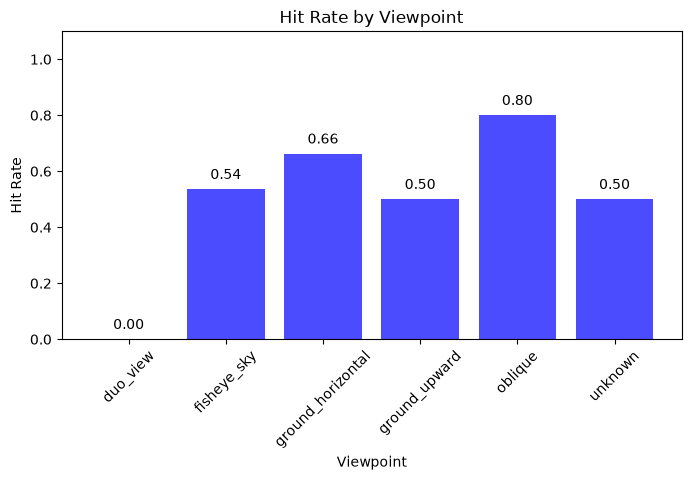

In [27]:
plot_single_bar_metric(viewpoint_metrics, x_column='viewpoint', metric='hit_rate', title='Hit Rate by Viewpoint', ylabel='Hit Rate', xlabel='Viewpoint')

### Diversity

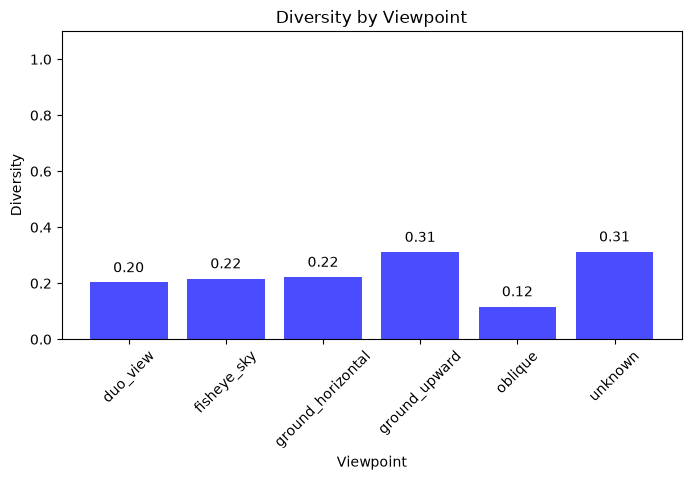

In [28]:
plot_single_bar_metric(viewpoint_metrics, x_column='viewpoint', metric='diversity', title='Diversity by Viewpoint', ylabel='Diversity', xlabel='Viewpoint')

### NDCG

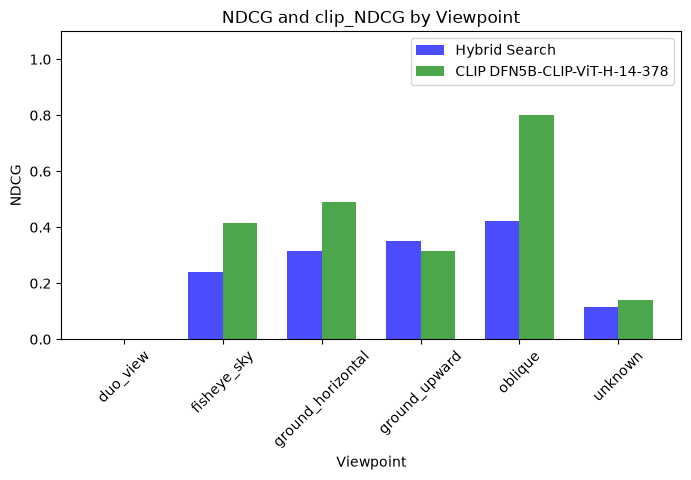

In [29]:
plot_rank_comparison(viewpoint_metrics, x_column='viewpoint', title='NDCG and clip_NDCG by Viewpoint', xlabel='Viewpoint')

### MRR

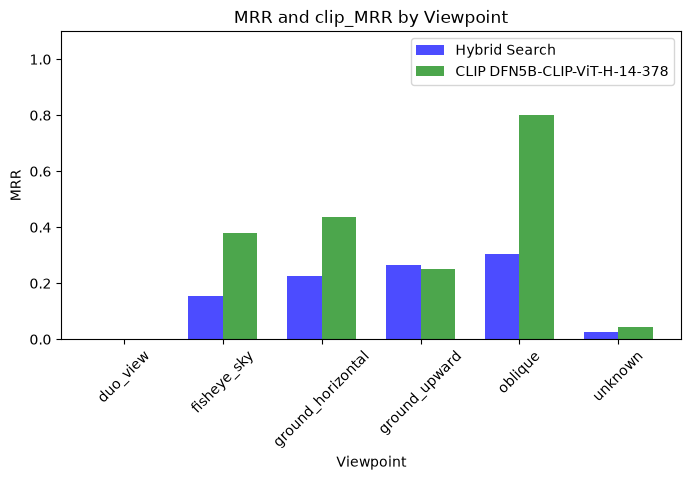

In [30]:
plot_rank_comparison(viewpoint_metrics, x_column='viewpoint', title='MRR and clip_MRR by Viewpoint', xlabel='Viewpoint', metric="MRR")

## Metrics based on Sky Condition

Now, we will evaluate queries based on sky condition.


In [31]:
# Group by sky_condition and calculate the sum/mean of each metric
sky_condition_metrics = df.groupby('sky_condition').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

#rename columns
sky_condition_metrics = sky_condition_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

sky_condition_metrics


,sky_condition,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,clear,1000,31,969,26,974,0.031000,0.026000,0.529167,0.600000,0.283903,0.463641,0.189752,0.419167,0.218028
1,fog_or_haze,225,7,218,5,220,0.031111,0.022222,0.500000,0.555556,0.348264,0.451290,0.246296,0.416667,0.194695
2,other,25,1,24,1,24,0.040000,0.040000,1.000000,1.000000,0.630930,1.000000,0.500000,1.000000,0.336118
3,overcast,500,19,481,15,485,0.038000,0.030000,0.650000,0.650000,0.339294,0.460372,0.286181,0.402976,0.243008
4,partly_cloudy,700,25,675,20,680,0.035714,0.028571,0.554762,0.678571,0.341593,0.543046,0.243646,0.500000,0.226372
5,unknown,550,20,530,12,538,0.036364,0.021818,0.545455,0.545455,0.182116,0.345564,0.089521,0.280647,0.211832


### Accuracy


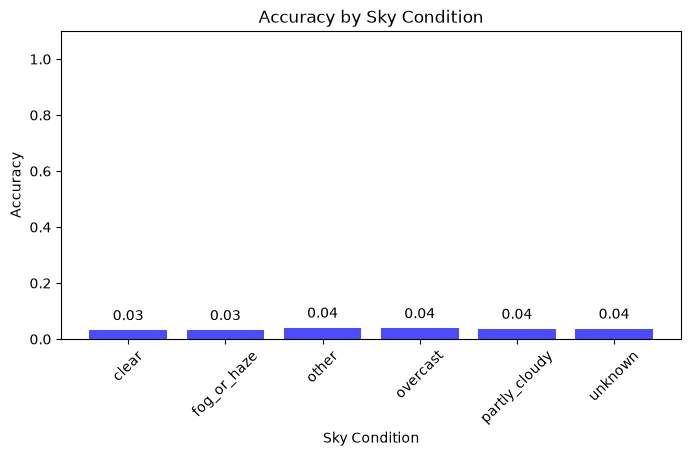

In [32]:
plot_single_bar_metric(sky_condition_metrics, x_column='sky_condition', metric='accuracy', title='Accuracy by Sky Condition', ylabel='Accuracy', xlabel='Sky Condition')


### Precision


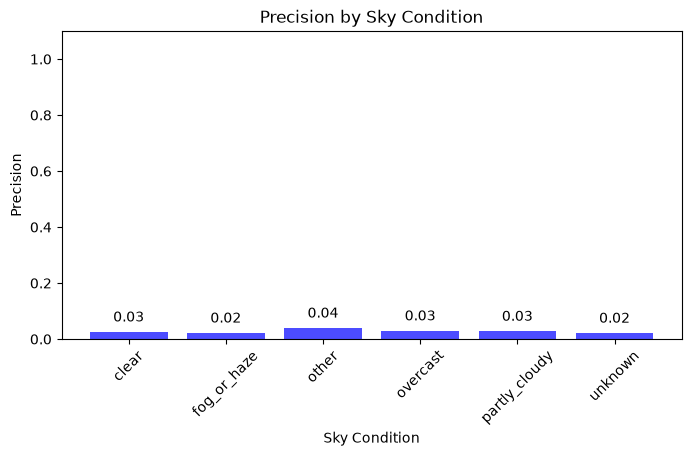

In [33]:
plot_single_bar_metric(sky_condition_metrics, x_column='sky_condition', metric='precision', title='Precision by Sky Condition', ylabel='Precision', xlabel='Sky Condition')


### Recall


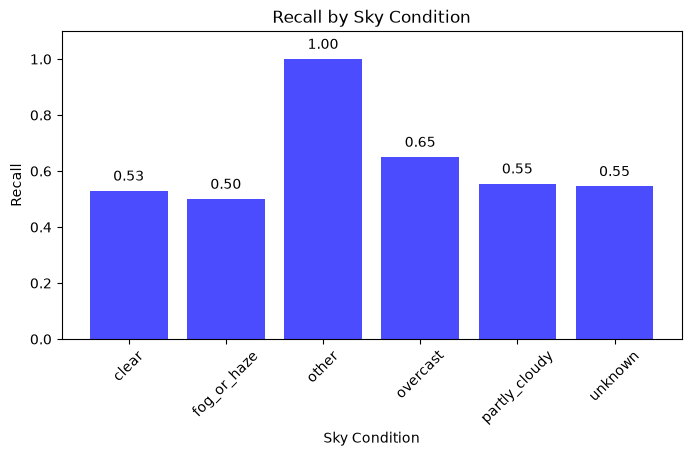

In [34]:
plot_single_bar_metric(sky_condition_metrics, x_column='sky_condition', metric='recall', title='Recall by Sky Condition', ylabel='Recall', xlabel='Sky Condition')


### Hit Rate


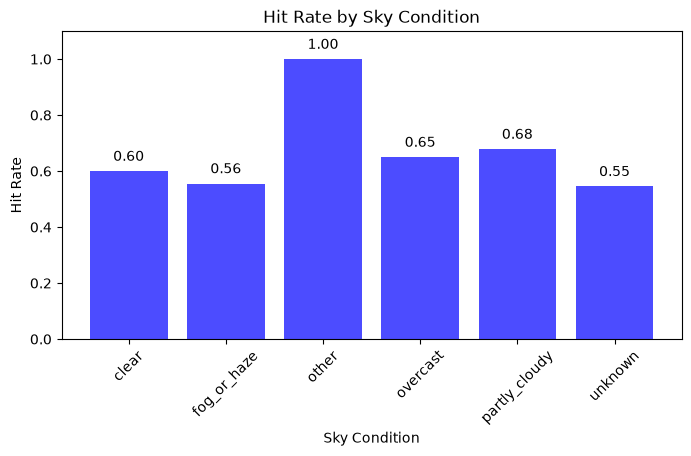

In [35]:
plot_single_bar_metric(sky_condition_metrics, x_column='sky_condition', metric='hit_rate', title='Hit Rate by Sky Condition', ylabel='Hit Rate', xlabel='Sky Condition')


### Diversity


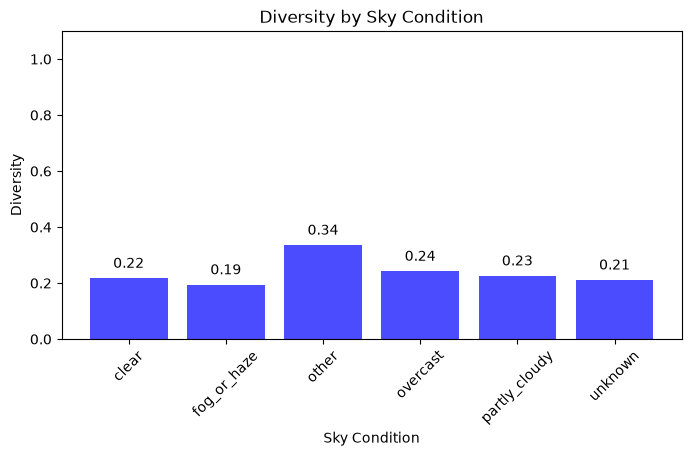

In [36]:
plot_single_bar_metric(sky_condition_metrics, x_column='sky_condition', metric='diversity', title='Diversity by Sky Condition', ylabel='Diversity', xlabel='Sky Condition')


### NDCG


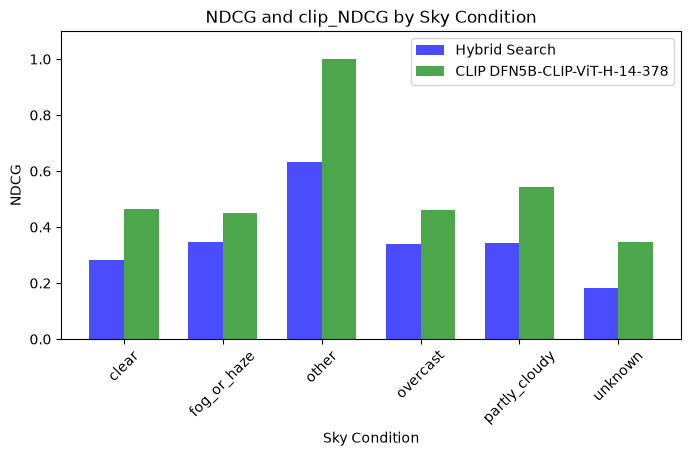

In [37]:
plot_rank_comparison(sky_condition_metrics, x_column='sky_condition', title='NDCG and clip_NDCG by Sky Condition', xlabel='Sky Condition')


### MRR


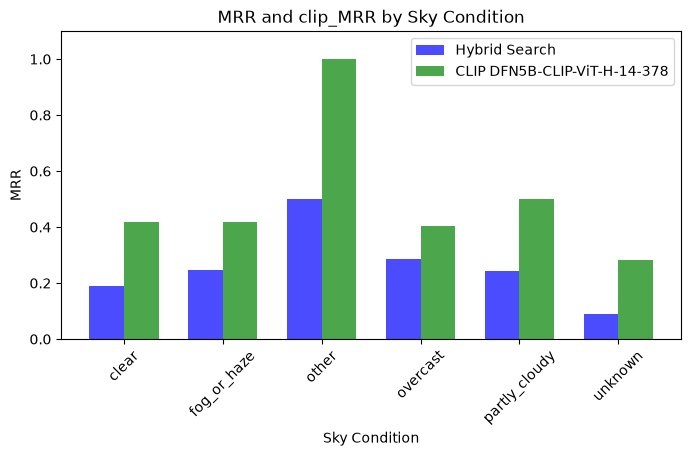

In [38]:
plot_rank_comparison(sky_condition_metrics, x_column='sky_condition', title='MRR and clip_MRR by Sky Condition', xlabel='Sky Condition', metric="MRR")


## Metrics based on Horizon Present

Now, we will evaluate queries based on **Horizon Present** (true vs false).


In [39]:
# Group by horizon_present and calculate the sum/mean of each metric
horizon_present_metrics = df.groupby('horizon_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
horizon_present_metrics['horizon_present'] = horizon_present_metrics['horizon_present'].map({True: 'True', False: 'False'})

#rename columns
horizon_present_metrics = horizon_present_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
horizon_present_metrics = horizon_present_metrics.sort_values('horizon_present')

horizon_present_metrics


,horizon_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,850,29,821,19,831,0.034118,0.022353,0.544118,0.558824,0.262678,0.407773,0.173048,0.358066,0.229967
1,True,2150,74,2076,60,2090,0.034419,0.027907,0.566279,0.639535,0.308691,0.485560,0.220212,0.436932,0.219180


### Accuracy


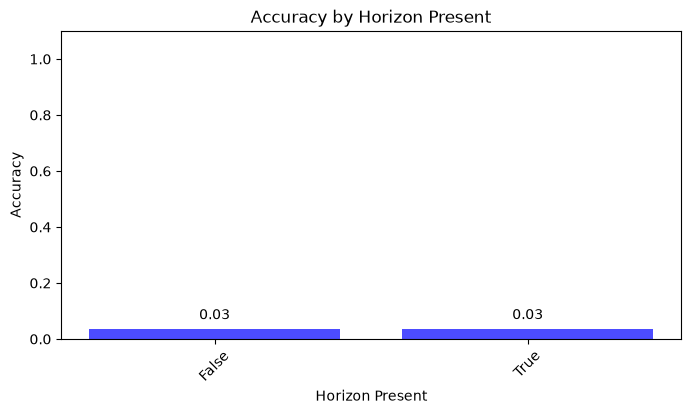

In [40]:
plot_single_bar_metric(horizon_present_metrics, x_column='horizon_present', metric='accuracy', title='Accuracy by Horizon Present', ylabel='Accuracy', xlabel='Horizon Present')


### Precision


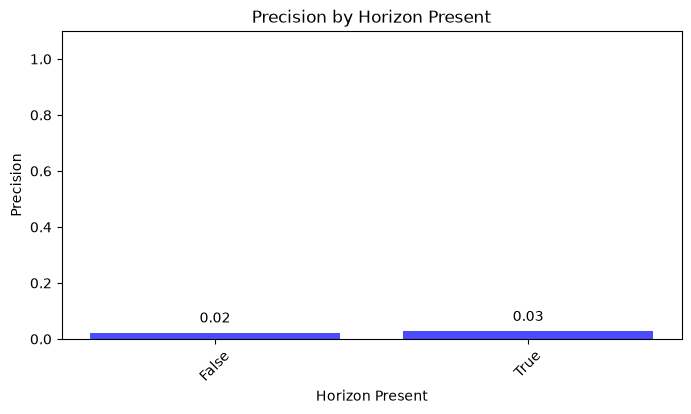

In [41]:
plot_single_bar_metric(horizon_present_metrics, x_column='horizon_present', metric='precision', title='Precision by Horizon Present', ylabel='Precision', xlabel='Horizon Present')


### Recall


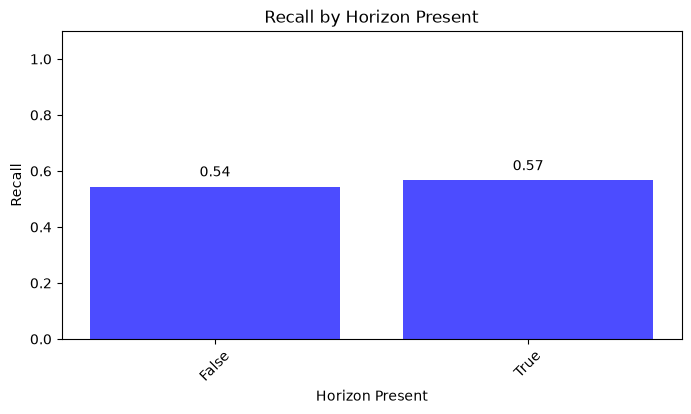

In [42]:
plot_single_bar_metric(horizon_present_metrics, x_column='horizon_present', metric='recall', title='Recall by Horizon Present', ylabel='Recall', xlabel='Horizon Present')


### Hit Rate


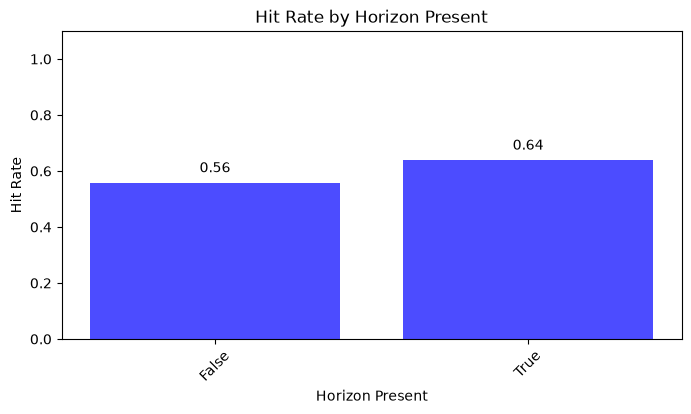

In [43]:
plot_single_bar_metric(horizon_present_metrics, x_column='horizon_present', metric='hit_rate', title='Hit Rate by Horizon Present', ylabel='Hit Rate', xlabel='Horizon Present')


### Diversity


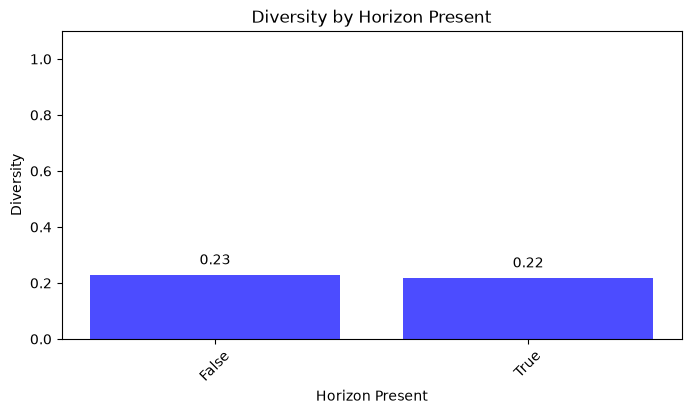

In [44]:
plot_single_bar_metric(horizon_present_metrics, x_column='horizon_present', metric='diversity', title='Diversity by Horizon Present', ylabel='Diversity', xlabel='Horizon Present')


### NDCG


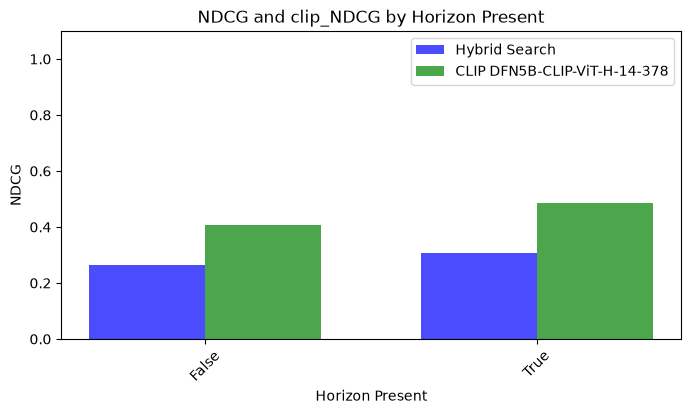

In [45]:
plot_rank_comparison(horizon_present_metrics, x_column='horizon_present', title='NDCG and clip_NDCG by Horizon Present', xlabel='Horizon Present')


### MRR


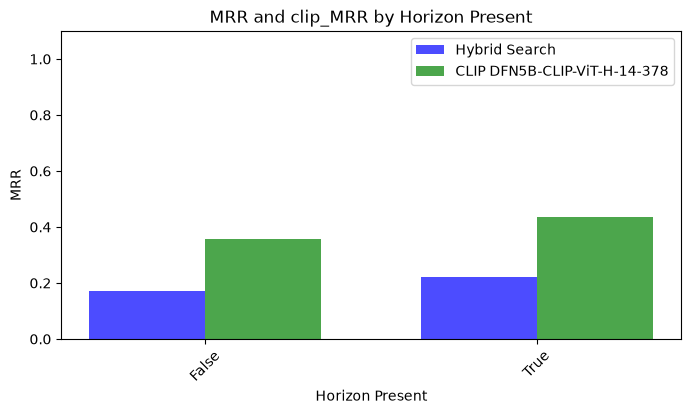

In [46]:
plot_rank_comparison(horizon_present_metrics, x_column='horizon_present', title='MRR and clip_MRR by Horizon Present', xlabel='Horizon Present', metric="MRR")


## Metrics based on Ground Present

Now, we will evaluate queries based on **Ground Present** (true vs false).


In [47]:
# Group by ground_present and calculate the sum/mean of each metric
ground_present_metrics = df.groupby('ground_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
ground_present_metrics['ground_present'] = ground_present_metrics['ground_present'].map({True: 'True', False: 'False'})


#rename columns
ground_present_metrics = ground_present_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
ground_present_metrics = ground_present_metrics.sort_values('ground_present')

ground_present_metrics


,ground_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,475,19,456,13,462,0.040000,0.027368,0.631579,0.631579,0.295955,0.433334,0.193336,0.368820,0.263356
1,True,2525,84,2441,66,2459,0.033267,0.026139,0.546535,0.613861,0.295597,0.469199,0.209391,0.423197,0.214501


### Accuracy


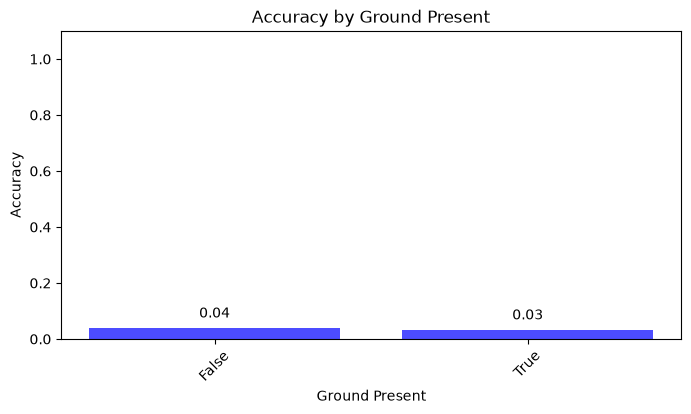

In [48]:
plot_single_bar_metric(ground_present_metrics, x_column='ground_present', metric='accuracy', title='Accuracy by Ground Present', ylabel='Accuracy', xlabel='Ground Present')


### Precision


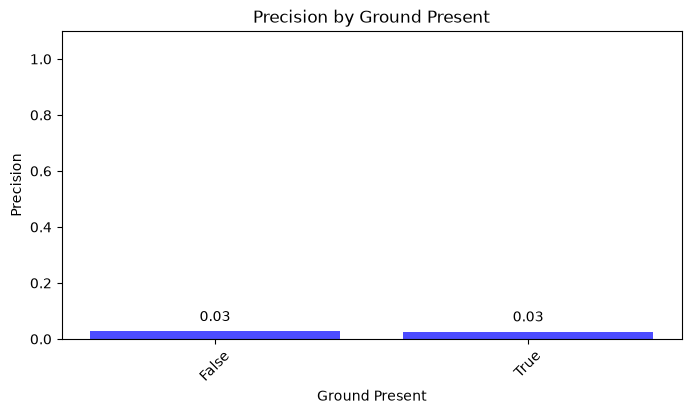

In [49]:
plot_single_bar_metric(ground_present_metrics, x_column='ground_present', metric='precision', title='Precision by Ground Present', ylabel='Precision', xlabel='Ground Present')


### Recall


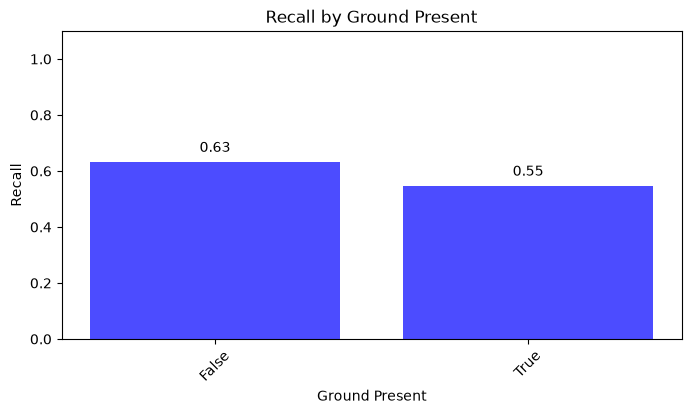

In [50]:
plot_single_bar_metric(ground_present_metrics, x_column='ground_present', metric='recall', title='Recall by Ground Present', ylabel='Recall', xlabel='Ground Present')


### Hit Rate


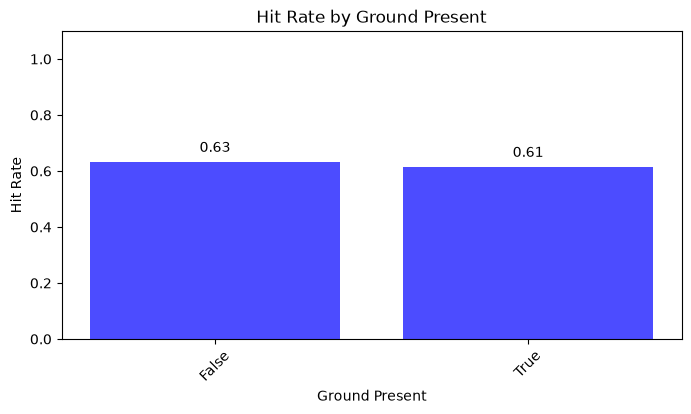

In [51]:
plot_single_bar_metric(ground_present_metrics, x_column='ground_present', metric='hit_rate', title='Hit Rate by Ground Present', ylabel='Hit Rate', xlabel='Ground Present')


### Diversity


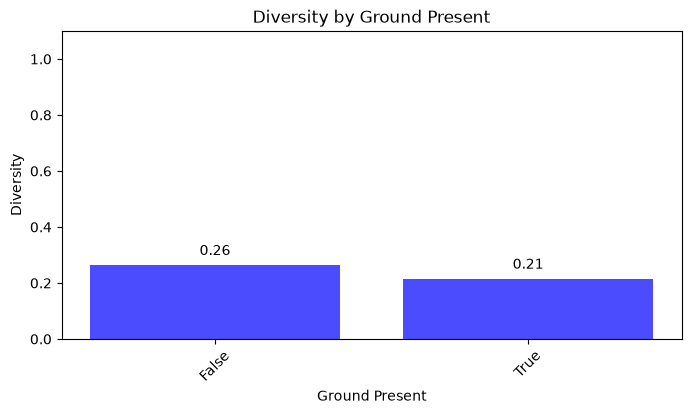

In [52]:
plot_single_bar_metric(ground_present_metrics, x_column='ground_present', metric='diversity', title='Diversity by Ground Present', ylabel='Diversity', xlabel='Ground Present')


### NDCG


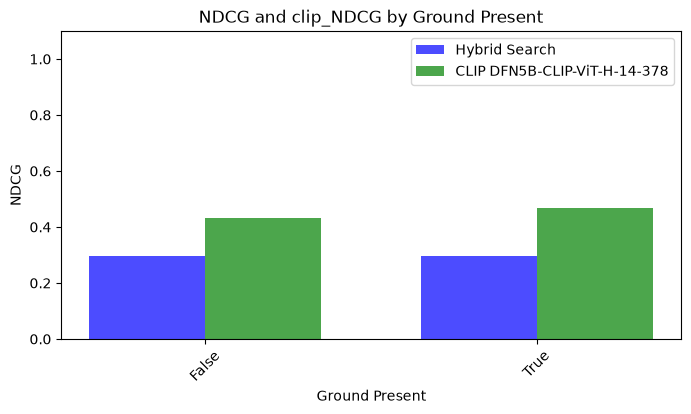

In [53]:
plot_rank_comparison(ground_present_metrics, x_column='ground_present', title='NDCG and clip_NDCG by Ground Present', xlabel='Ground Present')


### MRR


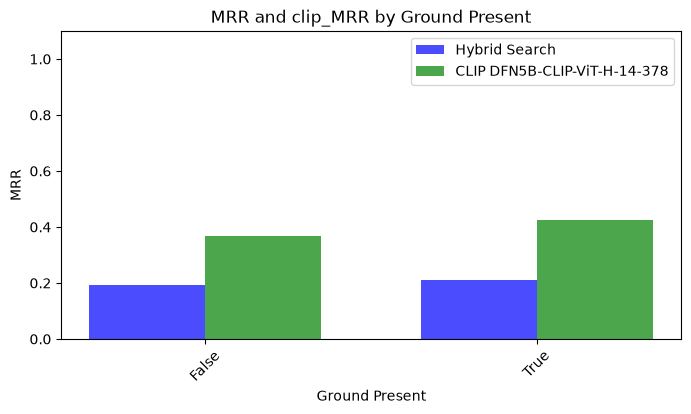

In [54]:
plot_rank_comparison(ground_present_metrics, x_column='ground_present', title='MRR and clip_MRR by Ground Present', xlabel='Ground Present', metric="MRR")


## Metrics based on Sky Dominates

Now, we will evaluate queries based on **Sky Dominates** (true vs false).


In [55]:
# Group by sky_dominates and calculate the sum/mean of each metric
sky_dominates_metrics = df.groupby('sky_dominates').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

sky_dominates_metrics['sky_dominates'] = sky_dominates_metrics['sky_dominates'].map({True: 'True', False: 'False'})

#rename columns
sky_dominates_metrics = sky_dominates_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
sky_dominates_metrics = sky_dominates_metrics.sort_values('sky_dominates')

sky_dominates_metrics


,sky_dominates,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,1800,63,1737,49,1751,0.035000,0.027222,0.590278,0.638889,0.300491,0.485067,0.215992,0.436349,0.210974
1,True,1200,40,1160,30,1170,0.033333,0.025000,0.514583,0.583333,0.288398,0.431200,0.193135,0.381944,0.239130


### Accuracy


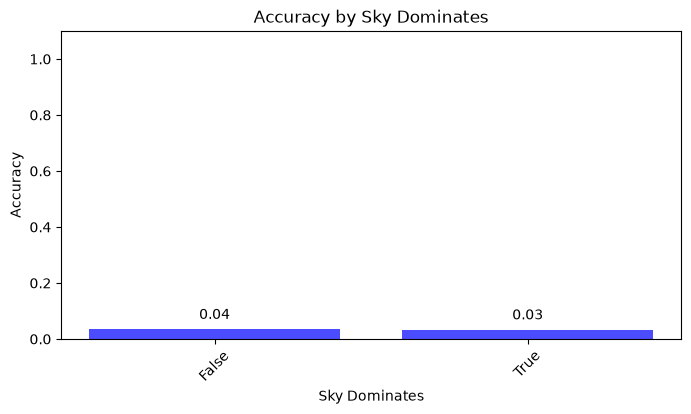

In [56]:
plot_single_bar_metric(sky_dominates_metrics, x_column='sky_dominates', metric='accuracy', title='Accuracy by Sky Dominates', ylabel='Accuracy', xlabel='Sky Dominates')


### Precision


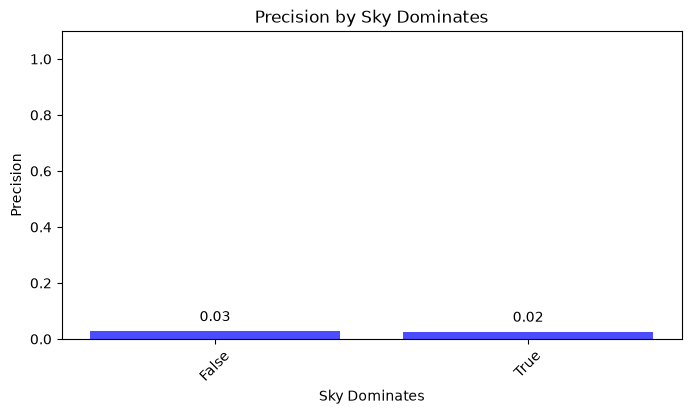

In [57]:
plot_single_bar_metric(sky_dominates_metrics, x_column='sky_dominates', metric='precision', title='Precision by Sky Dominates', ylabel='Precision', xlabel='Sky Dominates')


### Recall


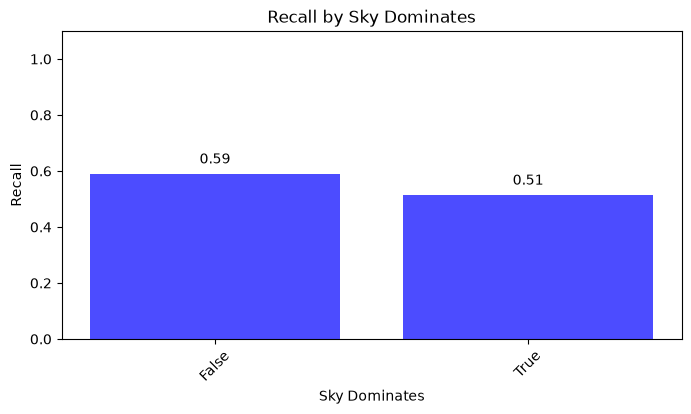

In [58]:
plot_single_bar_metric(sky_dominates_metrics, x_column='sky_dominates', metric='recall', title='Recall by Sky Dominates', ylabel='Recall', xlabel='Sky Dominates')


### Hit Rate


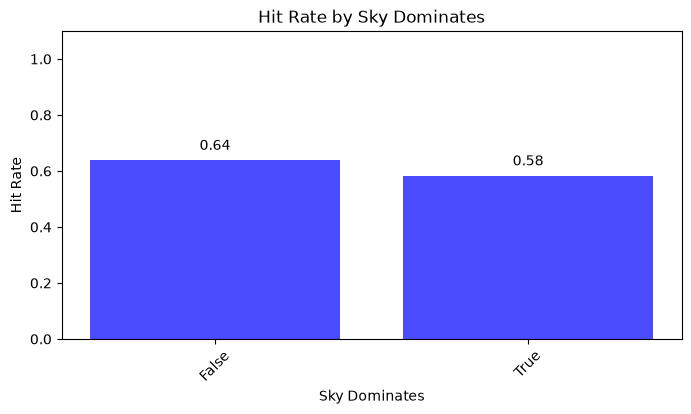

In [59]:
plot_single_bar_metric(sky_dominates_metrics, x_column='sky_dominates', metric='hit_rate', title='Hit Rate by Sky Dominates', ylabel='Hit Rate', xlabel='Sky Dominates')


### Diversity


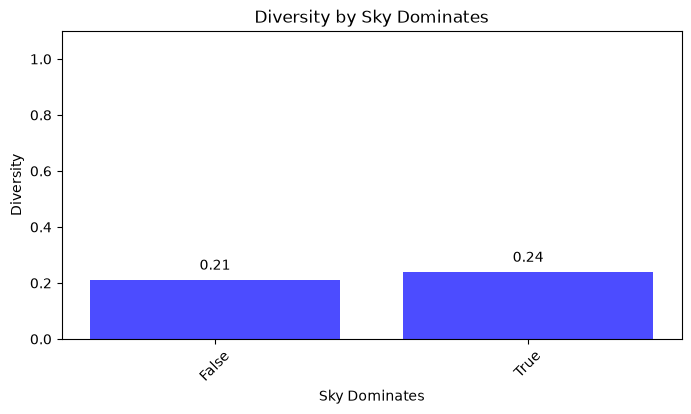

In [60]:
plot_single_bar_metric(sky_dominates_metrics, x_column='sky_dominates', metric='diversity', title='Diversity by Sky Dominates', ylabel='Diversity', xlabel='Sky Dominates')


### NDCG


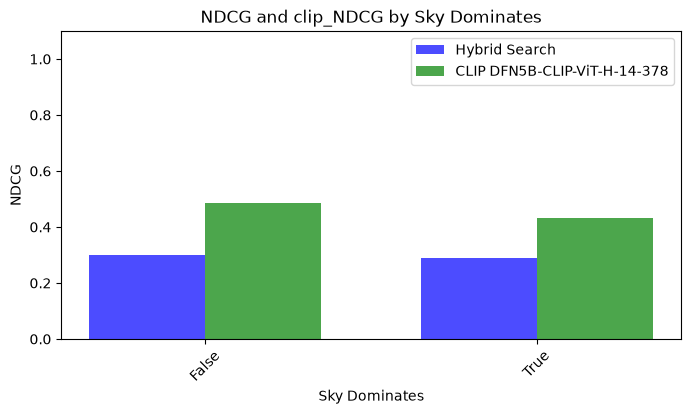

In [61]:
plot_rank_comparison(sky_dominates_metrics, x_column='sky_dominates', title='NDCG and clip_NDCG by Sky Dominates', xlabel='Sky Dominates')


### MRR


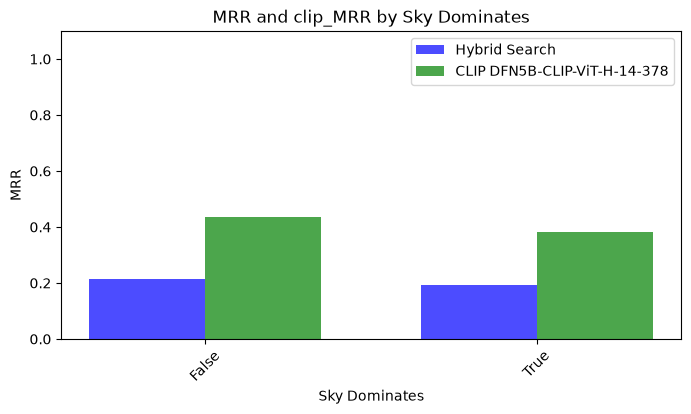

In [62]:
plot_rank_comparison(sky_dominates_metrics, x_column='sky_dominates', title='MRR and clip_MRR by Sky Dominates', xlabel='Sky Dominates', metric="MRR")


## Metrics based on Vegetation Present

Now, we will evaluate queries based on **Vegetation Present** (true vs false).


In [63]:
# Group by vegetation_present and calculate the sum/mean of each metric
vegetation_present_metrics = df.groupby('vegetation_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

vegetation_present_metrics['vegetation_present'] = vegetation_present_metrics['vegetation_present'].map({True: 'True', False: 'False'})


#rename columns
vegetation_present_metrics = vegetation_present_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
vegetation_present_metrics = vegetation_present_metrics.sort_values('vegetation_present')

vegetation_present_metrics


,vegetation_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,1125,36,1089,24,1101,0.032000,0.021333,0.466667,0.488889,0.227213,0.351150,0.14878,0.308316,0.213583
1,True,1875,67,1808,55,1820,0.035733,0.029333,0.616000,0.693333,0.336718,0.530942,0.24169,0.478349,0.227429


### Accuracy


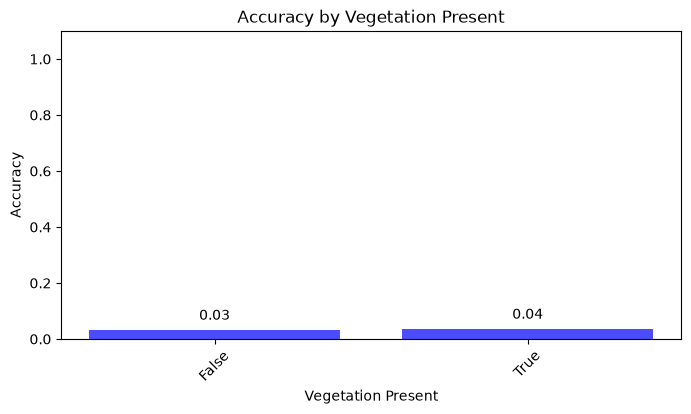

In [64]:
plot_single_bar_metric(vegetation_present_metrics, x_column='vegetation_present', metric='accuracy', title='Accuracy by Vegetation Present', ylabel='Accuracy', xlabel='Vegetation Present')


### Precision


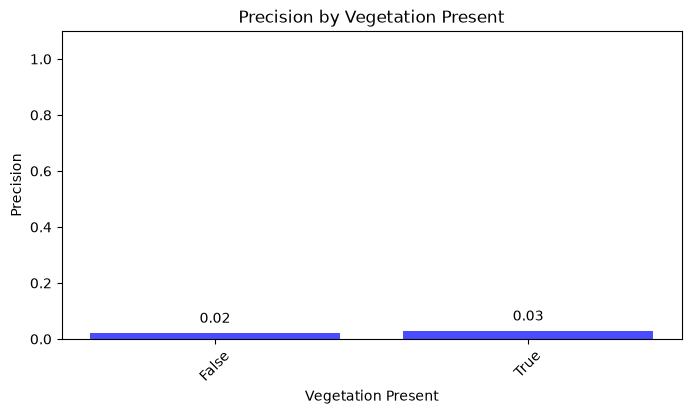

In [65]:
plot_single_bar_metric(vegetation_present_metrics, x_column='vegetation_present', metric='precision', title='Precision by Vegetation Present', ylabel='Precision', xlabel='Vegetation Present')


### Recall


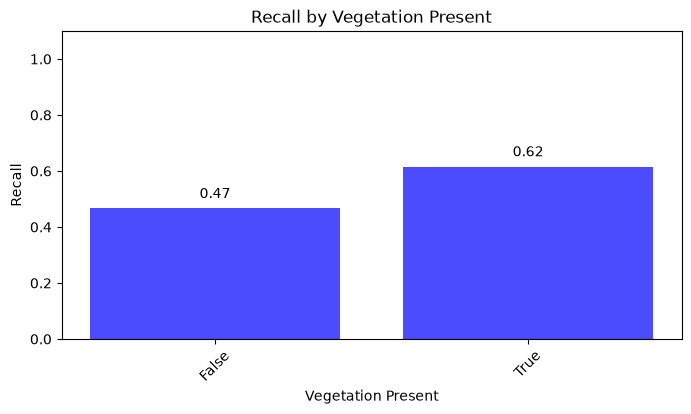

In [66]:
plot_single_bar_metric(vegetation_present_metrics, x_column='vegetation_present', metric='recall', title='Recall by Vegetation Present', ylabel='Recall', xlabel='Vegetation Present')


### Hit Rate


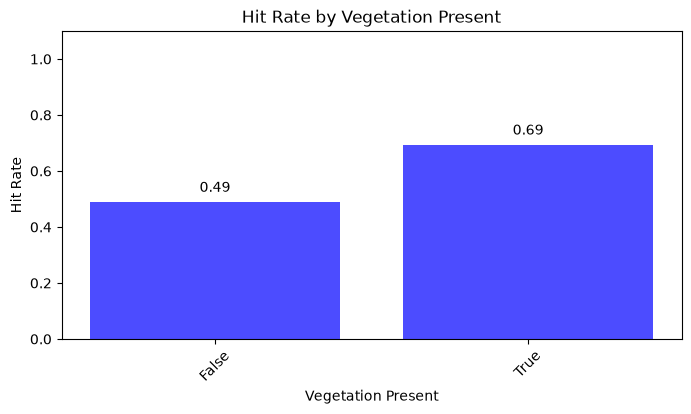

In [67]:
plot_single_bar_metric(vegetation_present_metrics, x_column='vegetation_present', metric='hit_rate', title='Hit Rate by Vegetation Present', ylabel='Hit Rate', xlabel='Vegetation Present')


### Diversity


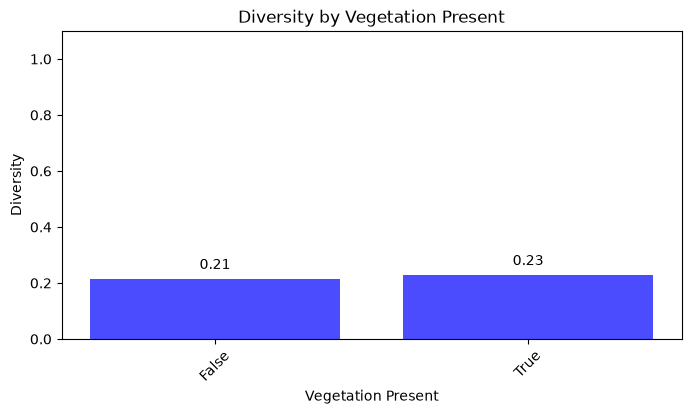

In [68]:
plot_single_bar_metric(vegetation_present_metrics, x_column='vegetation_present', metric='diversity', title='Diversity by Vegetation Present', ylabel='Diversity', xlabel='Vegetation Present')


### NDCG


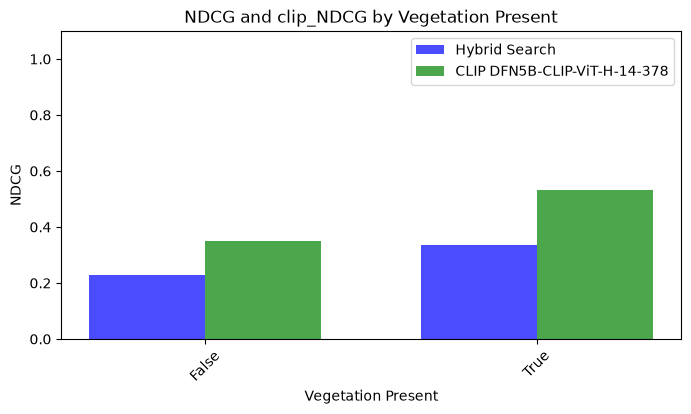

In [69]:
plot_rank_comparison(vegetation_present_metrics, x_column='vegetation_present', title='NDCG and clip_NDCG by Vegetation Present', xlabel='Vegetation Present')


### MRR


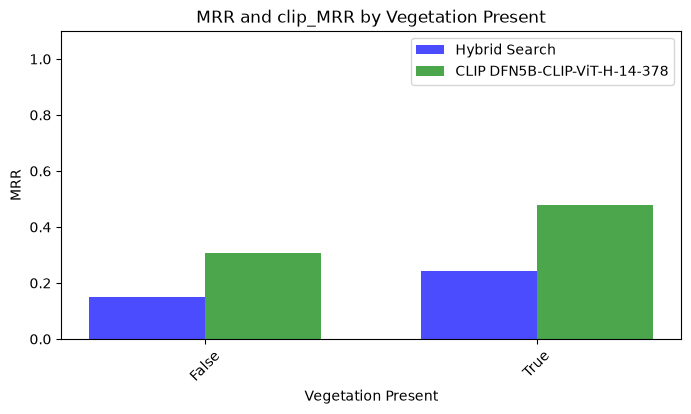

In [70]:
plot_rank_comparison(vegetation_present_metrics, x_column='vegetation_present', title='MRR and clip_MRR by Vegetation Present', xlabel='Vegetation Present', metric="MRR")


## Metrics based on Water Present

Now, we will evaluate queries based on **Water Present** (true vs false).


In [71]:
# Group by water_present and calculate the sum/mean of each metric
water_present_metrics = df.groupby('water_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

water_present_metrics['water_present'] = water_present_metrics['water_present'].map({True: 'True', False: 'False'})

#rename columns
water_present_metrics = water_present_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
water_present_metrics = water_present_metrics.sort_values('water_present')

water_present_metrics


,water_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,2825,95,2730,72,2753,0.033628,0.025487,0.532743,0.59292,0.272995,0.449936,0.178470,0.404576,0.215769
1,True,175,8,167,7,168,0.045714,0.040000,1.000000,1.00000,0.661436,0.682806,0.664966,0.576190,0.326635


### Accuracy


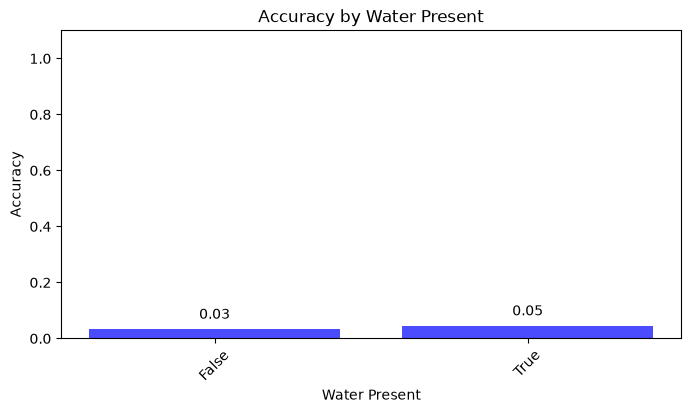

In [72]:
plot_single_bar_metric(water_present_metrics, x_column='water_present', metric='accuracy', title='Accuracy by Water Present', ylabel='Accuracy', xlabel='Water Present')


### Precision


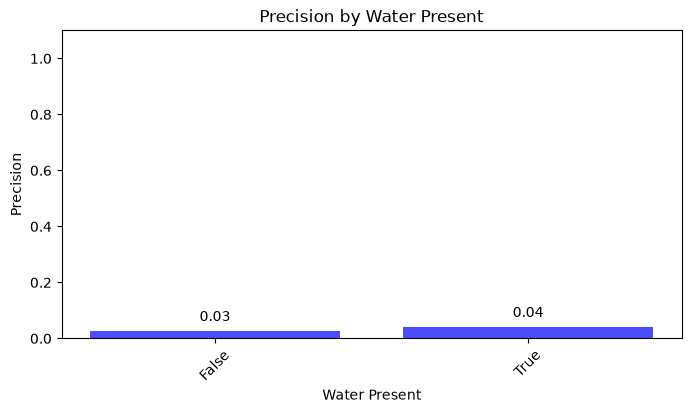

In [73]:
plot_single_bar_metric(water_present_metrics, x_column='water_present', metric='precision', title='Precision by Water Present', ylabel='Precision', xlabel='Water Present')


### Recall


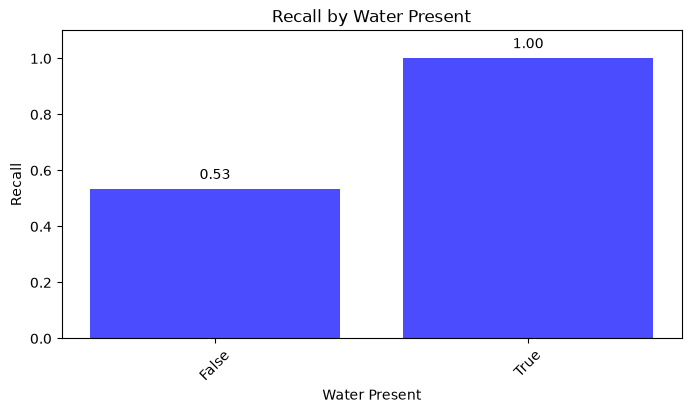

In [74]:
plot_single_bar_metric(water_present_metrics, x_column='water_present', metric='recall', title='Recall by Water Present', ylabel='Recall', xlabel='Water Present')


### Hit Rate


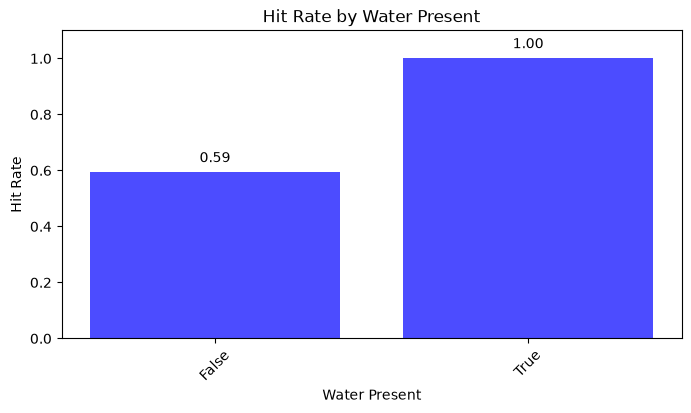

In [75]:
plot_single_bar_metric(water_present_metrics, x_column='water_present', metric='hit_rate', title='Hit Rate by Water Present', ylabel='Hit Rate', xlabel='Water Present')


### Diversity


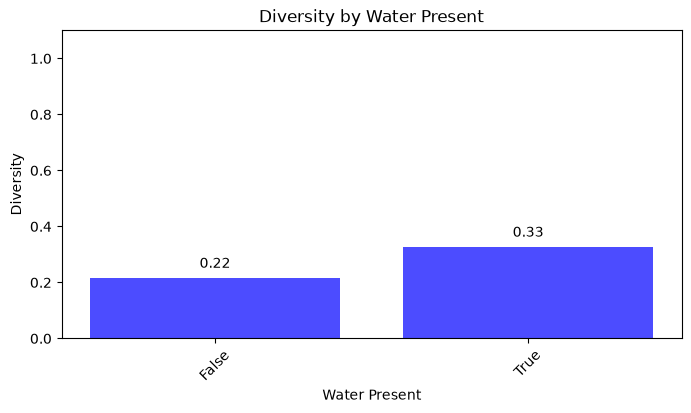

In [76]:
plot_single_bar_metric(water_present_metrics, x_column='water_present', metric='diversity', title='Diversity by Water Present', ylabel='Diversity', xlabel='Water Present')


### NDCG


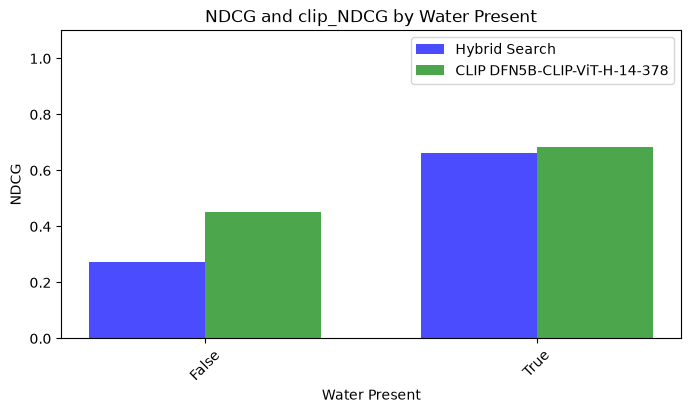

In [77]:
plot_rank_comparison(water_present_metrics, x_column='water_present', title='NDCG and clip_NDCG by Water Present', xlabel='Water Present')


### MRR


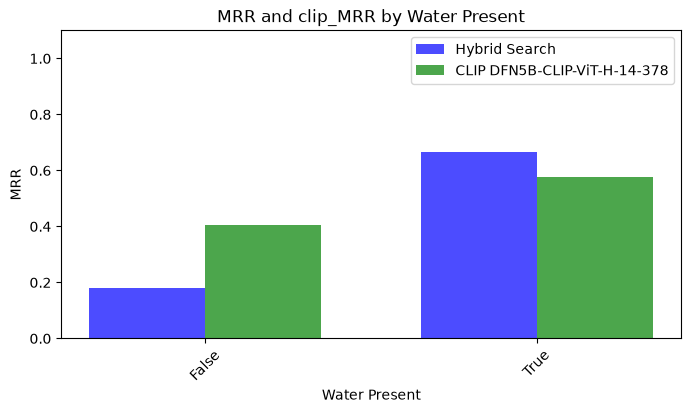

In [78]:
plot_rank_comparison(water_present_metrics, x_column='water_present', title='MRR and clip_MRR by Water Present', xlabel='Water Present', metric="MRR")


## Metrics based on Buildings Present

Now, we will evaluate queries based on **Buildings Present** (true vs false).


In [79]:
# Group by buildings_present and calculate the sum/mean of each metric
buildings_present_metrics = df.groupby('buildings_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

buildings_present_metrics['buildings_present'] = buildings_present_metrics['buildings_present'].map({True: 'True', False: 'False'})

#rename columns
buildings_present_metrics = buildings_present_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
buildings_present_metrics = buildings_present_metrics.sort_values('buildings_present')

buildings_present_metrics


,buildings_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,1950,64,1886,53,1897,0.032821,0.027179,0.560256,0.628205,0.304217,0.490233,0.214519,0.446159,0.228657
1,True,1050,39,1011,26,1024,0.037143,0.024762,0.559524,0.595238,0.279750,0.413909,0.192605,0.355952,0.210312


### Accuracy


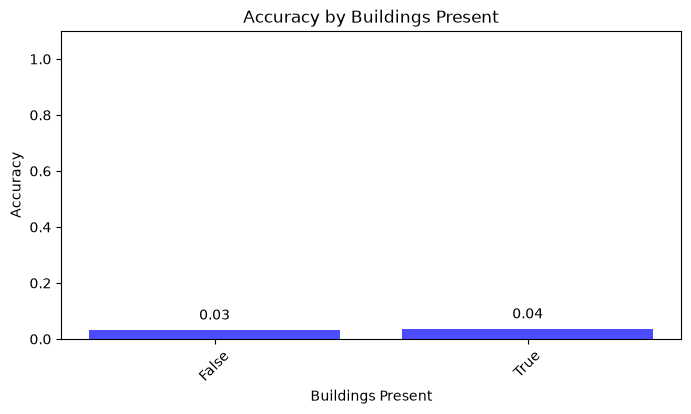

In [80]:
plot_single_bar_metric(buildings_present_metrics, x_column='buildings_present', metric='accuracy', title='Accuracy by Buildings Present', ylabel='Accuracy', xlabel='Buildings Present')


### Precision


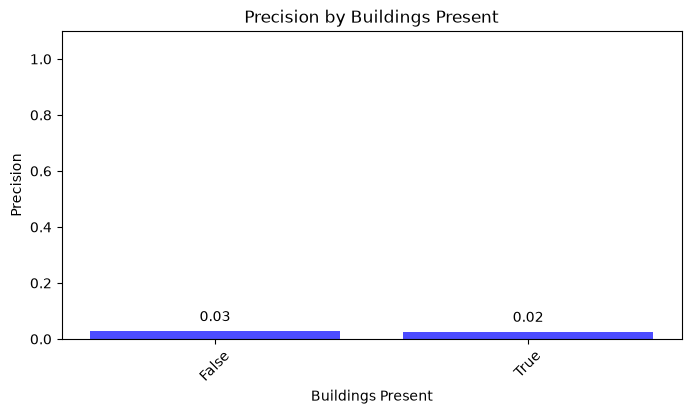

In [81]:
plot_single_bar_metric(buildings_present_metrics, x_column='buildings_present', metric='precision', title='Precision by Buildings Present', ylabel='Precision', xlabel='Buildings Present')


### Recall


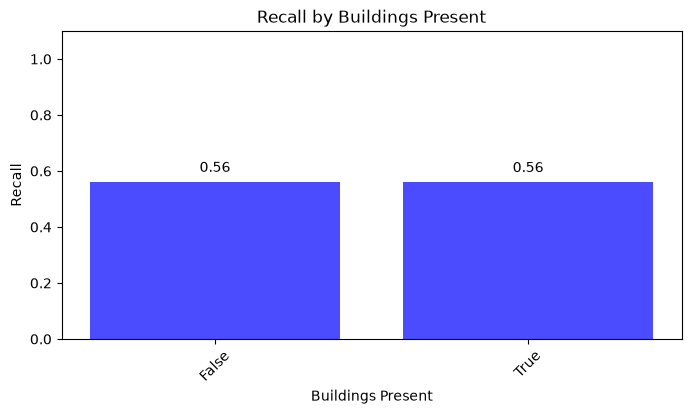

In [82]:
plot_single_bar_metric(buildings_present_metrics, x_column='buildings_present', metric='recall', title='Recall by Buildings Present', ylabel='Recall', xlabel='Buildings Present')


### Hit Rate


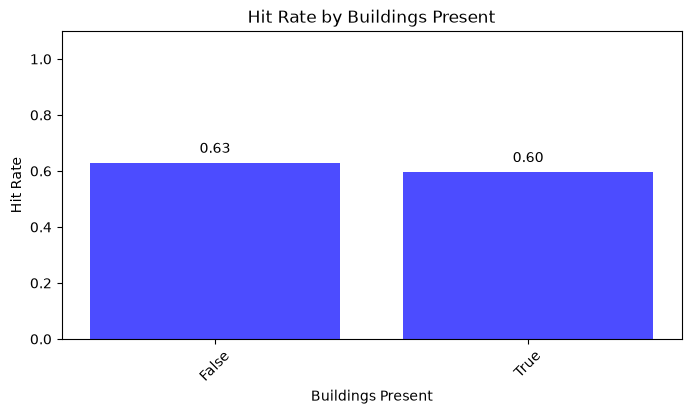

In [83]:
plot_single_bar_metric(buildings_present_metrics, x_column='buildings_present', metric='hit_rate', title='Hit Rate by Buildings Present', ylabel='Hit Rate', xlabel='Buildings Present')


### Diversity


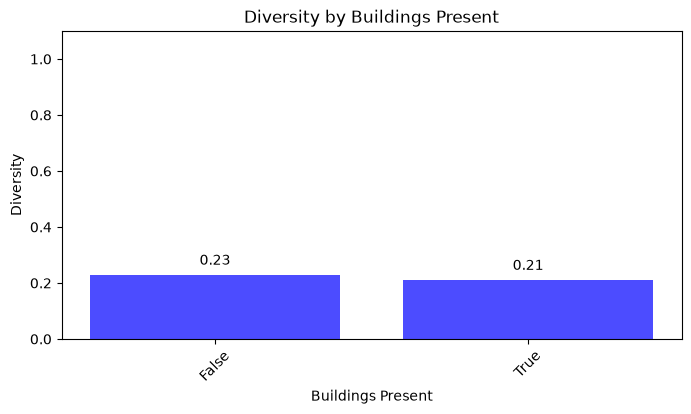

In [84]:
plot_single_bar_metric(buildings_present_metrics, x_column='buildings_present', metric='diversity', title='Diversity by Buildings Present', ylabel='Diversity', xlabel='Buildings Present')


### NDCG


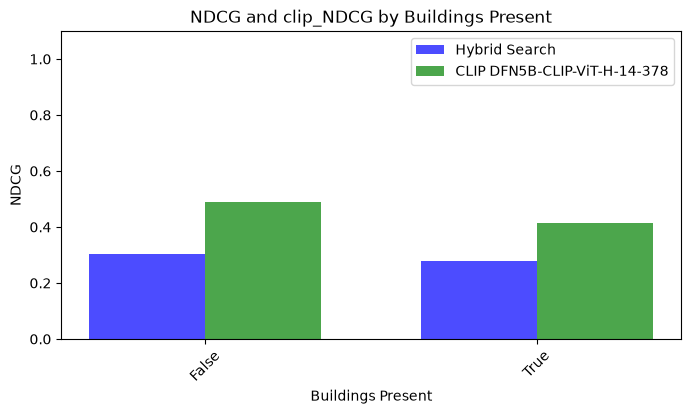

In [85]:
plot_rank_comparison(buildings_present_metrics, x_column='buildings_present', title='NDCG and clip_NDCG by Buildings Present', xlabel='Buildings Present')


### MRR


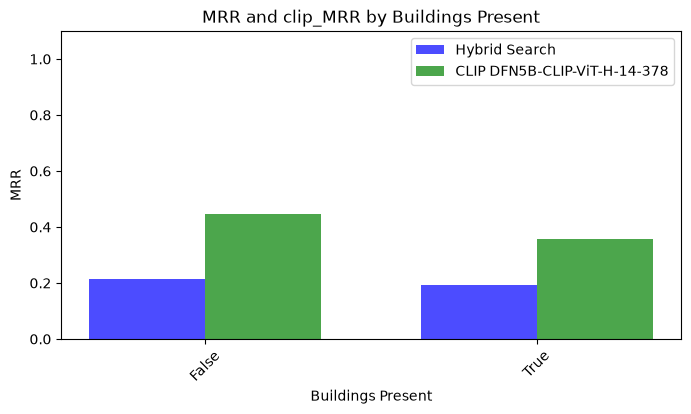

In [86]:
plot_rank_comparison(buildings_present_metrics, x_column='buildings_present', title='MRR and clip_MRR by Buildings Present', xlabel='Buildings Present', metric="MRR")


## Metrics based on Vehicle Present

Now, we will evaluate queries based on **Vehicle Present** (true vs false).


In [87]:
# Group by vehicle_present and calculate the sum/mean of each metric
vehicle_present_metrics = df.groupby('vehicle_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

vehicle_present_metrics['vehicle_present'] = vehicle_present_metrics['vehicle_present'].map({True: 'True', False: 'False'})


#rename columns
vehicle_present_metrics = vehicle_present_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
vehicle_present_metrics = vehicle_present_metrics.sort_values('vehicle_present')

vehicle_present_metrics


,vehicle_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,2850,95,2755,73,2777,0.033333,0.025614,0.541228,0.596491,0.287008,0.451139,0.199948,0.404975,0.217896
1,True,150,8,142,6,144,0.053333,0.040000,0.916667,1.000000,0.459931,0.698756,0.337963,0.597222,0.304713


### Accuracy


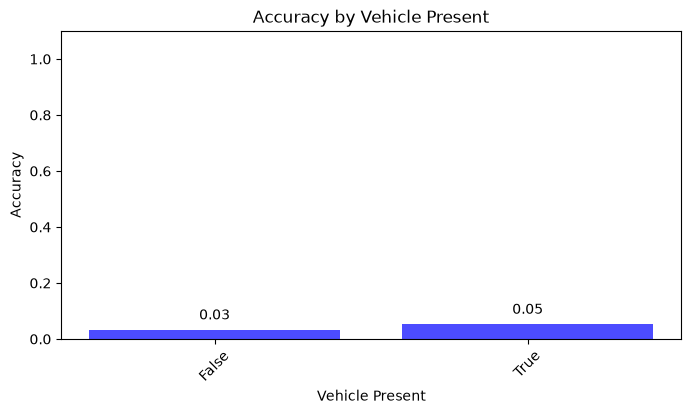

In [88]:
plot_single_bar_metric(vehicle_present_metrics, x_column='vehicle_present', metric='accuracy', title='Accuracy by Vehicle Present', ylabel='Accuracy', xlabel='Vehicle Present')


### Precision


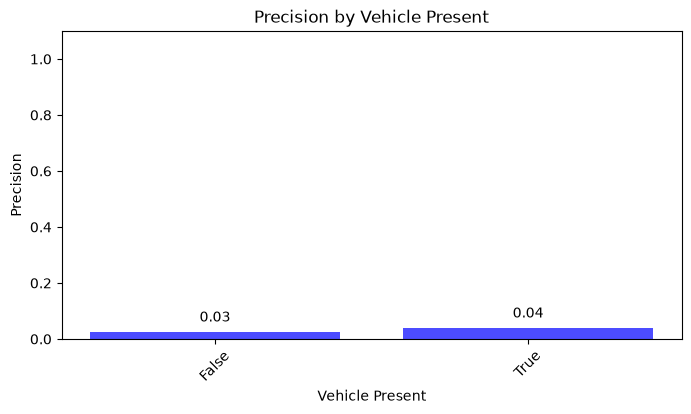

In [89]:
plot_single_bar_metric(vehicle_present_metrics, x_column='vehicle_present', metric='precision', title='Precision by Vehicle Present', ylabel='Precision', xlabel='Vehicle Present')


### Recall


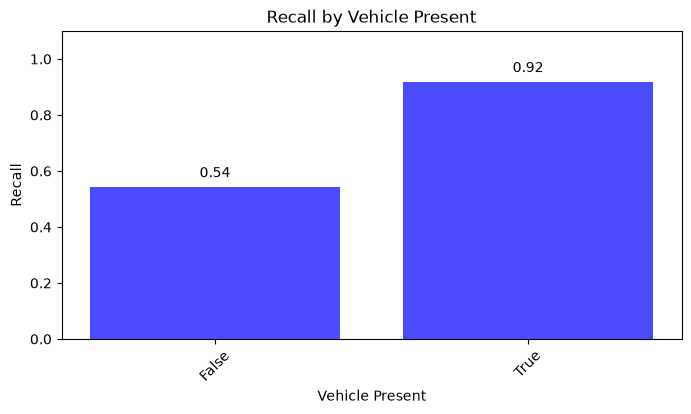

In [90]:
plot_single_bar_metric(vehicle_present_metrics, x_column='vehicle_present', metric='recall', title='Recall by Vehicle Present', ylabel='Recall', xlabel='Vehicle Present')


### Hit Rate


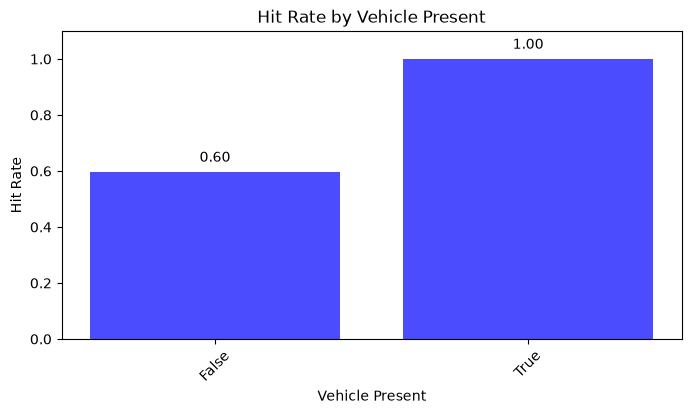

In [91]:
plot_single_bar_metric(vehicle_present_metrics, x_column='vehicle_present', metric='hit_rate', title='Hit Rate by Vehicle Present', ylabel='Hit Rate', xlabel='Vehicle Present')


### Diversity


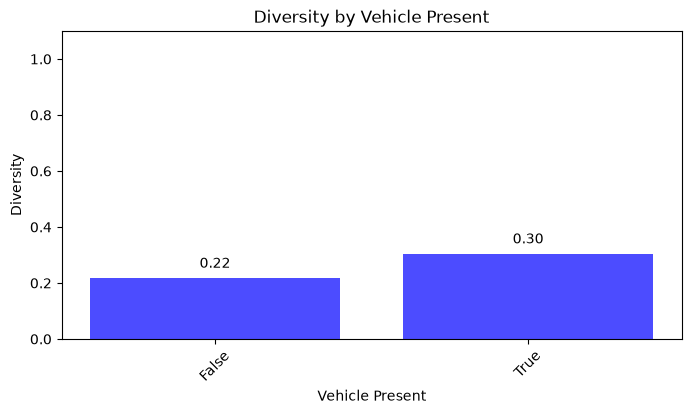

In [92]:
plot_single_bar_metric(vehicle_present_metrics, x_column='vehicle_present', metric='diversity', title='Diversity by Vehicle Present', ylabel='Diversity', xlabel='Vehicle Present')


### NDCG


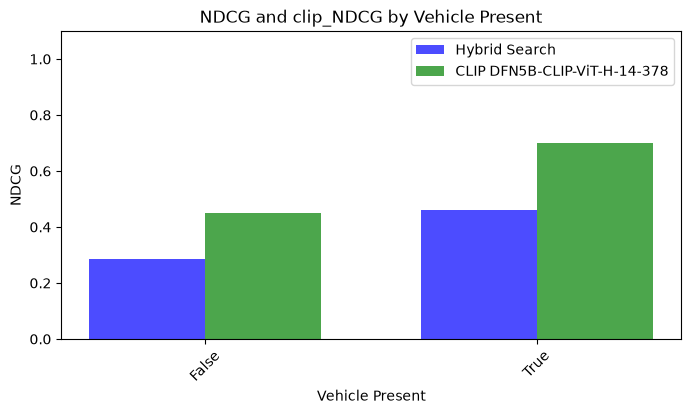

In [93]:
plot_rank_comparison(vehicle_present_metrics, x_column='vehicle_present', title='NDCG and clip_NDCG by Vehicle Present', xlabel='Vehicle Present')


### MRR


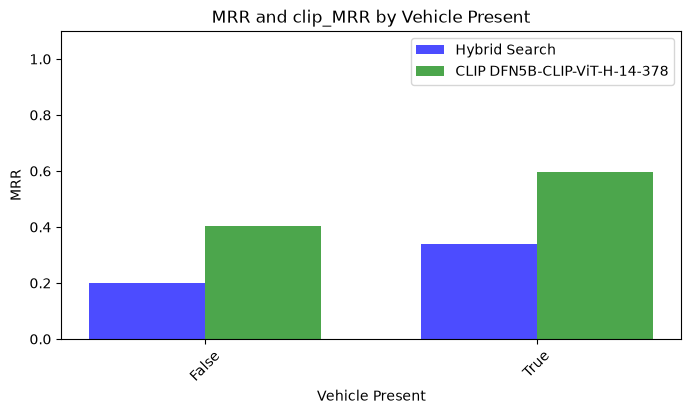

In [94]:
plot_rank_comparison(vehicle_present_metrics, x_column='vehicle_present', title='MRR and clip_MRR by Vehicle Present', xlabel='Vehicle Present', metric="MRR")


## Metrics based on Person Present

Now, we will evaluate queries based on **Person Present** (true vs false).


In [95]:
# Group by person_present and calculate the sum/mean of each metric
person_present_metrics = df.groupby('person_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

person_present_metrics['person_present'] = person_present_metrics['person_present'].map({True: 'True', False: 'False'})

#rename columns
person_present_metrics = person_present_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
person_present_metrics = person_present_metrics.sort_values('person_present')

person_present_metrics


,person_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,3000,103,2897,79,2921,0.034333,0.026333,0.56,0.616667,0.295654,0.46352,0.206849,0.414587,0.222237


### Accuracy


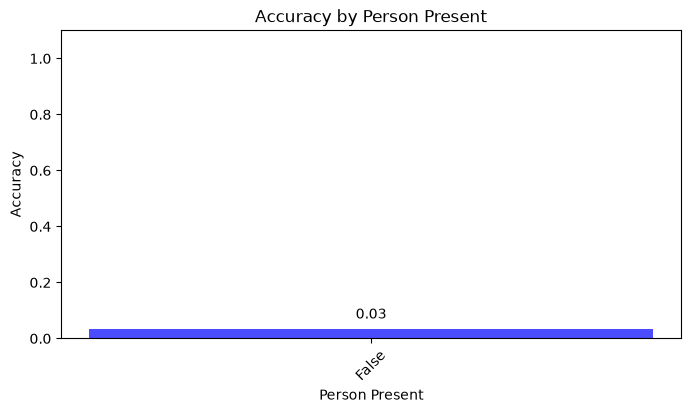

In [96]:
plot_single_bar_metric(person_present_metrics, x_column='person_present', metric='accuracy', title='Accuracy by Person Present', ylabel='Accuracy', xlabel='Person Present')


### Precision


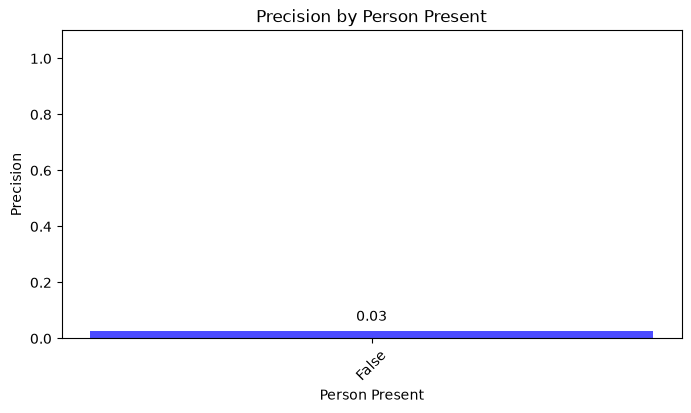

In [97]:
plot_single_bar_metric(person_present_metrics, x_column='person_present', metric='precision', title='Precision by Person Present', ylabel='Precision', xlabel='Person Present')


### Recall


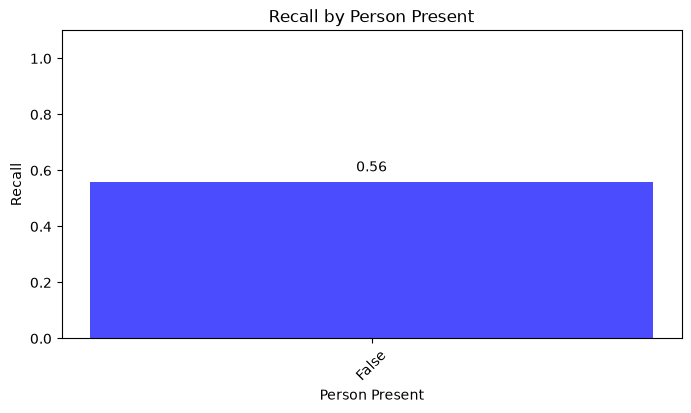

In [98]:
plot_single_bar_metric(person_present_metrics, x_column='person_present', metric='recall', title='Recall by Person Present', ylabel='Recall', xlabel='Person Present')


### Hit Rate


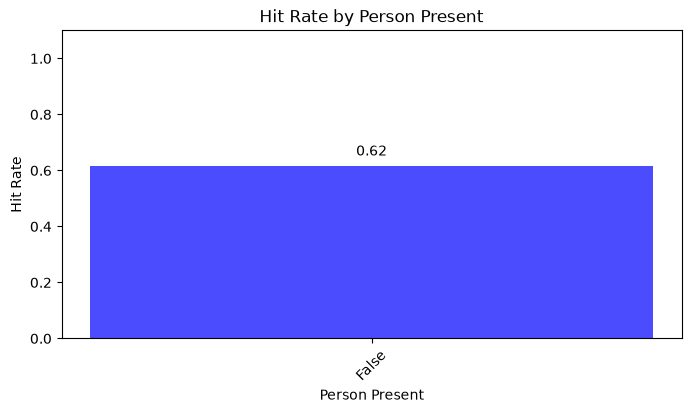

In [99]:
plot_single_bar_metric(person_present_metrics, x_column='person_present', metric='hit_rate', title='Hit Rate by Person Present', ylabel='Hit Rate', xlabel='Person Present')


### Diversity


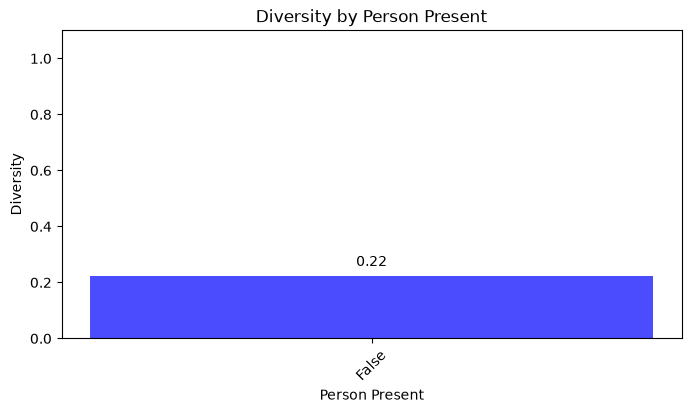

In [100]:
plot_single_bar_metric(person_present_metrics, x_column='person_present', metric='diversity', title='Diversity by Person Present', ylabel='Diversity', xlabel='Person Present')


### NDCG


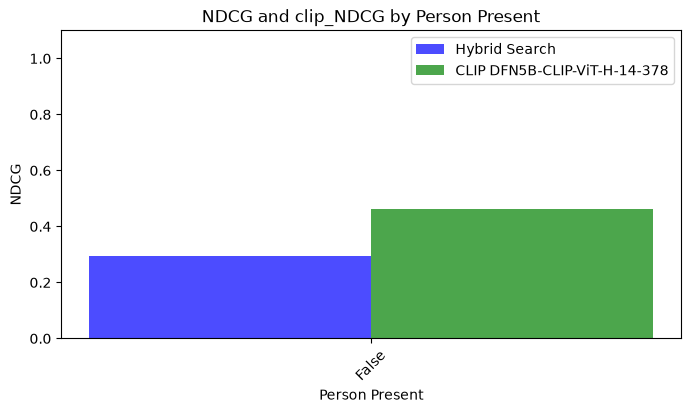

In [101]:
plot_rank_comparison(person_present_metrics, x_column='person_present', title='NDCG and clip_NDCG by Person Present', xlabel='Person Present')


### MRR


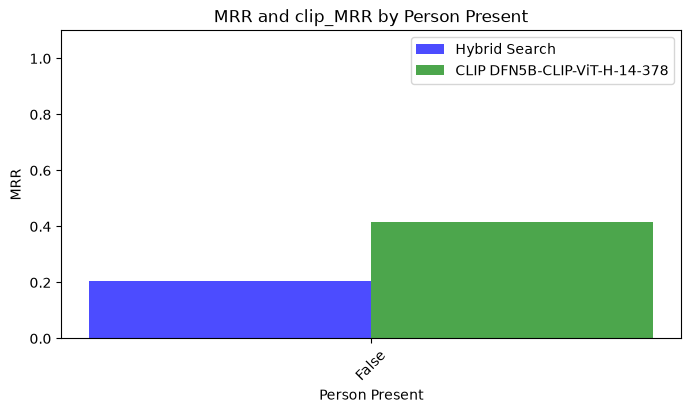

In [102]:
plot_rank_comparison(person_present_metrics, x_column='person_present', title='MRR and clip_MRR by Person Present', xlabel='Person Present', metric="MRR")


## Metrics based on Animal Present

Now, we will evaluate queries based on **Animal Present** (true vs false).


In [103]:
# Group by animal_present and calculate the sum/mean of each metric
animal_present_metrics = df.groupby('animal_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

animal_present_metrics['animal_present'] = animal_present_metrics['animal_present'].map({True: 'True', False: 'False'})

#rename columns
animal_present_metrics = animal_present_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
animal_present_metrics = animal_present_metrics.sort_values('animal_present')

animal_present_metrics


,animal_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,3000,103,2897,79,2921,0.034333,0.026333,0.56,0.616667,0.295654,0.46352,0.206849,0.414587,0.222237


### Accuracy


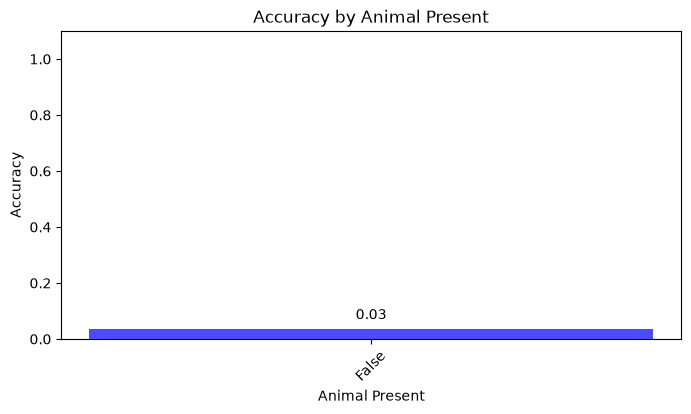

In [104]:
plot_single_bar_metric(animal_present_metrics, x_column='animal_present', metric='accuracy', title='Accuracy by Animal Present', ylabel='Accuracy', xlabel='Animal Present')


### Precision


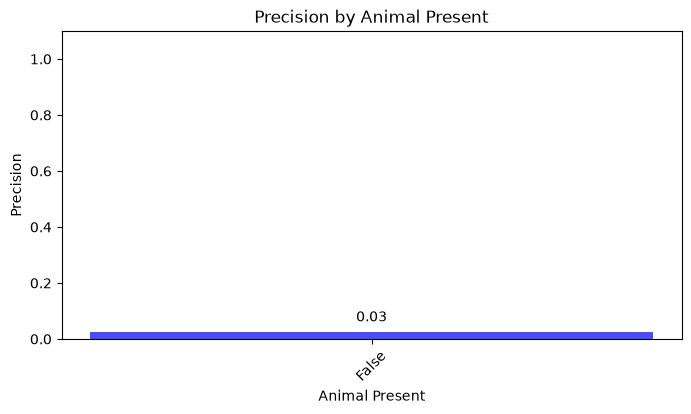

In [105]:
plot_single_bar_metric(animal_present_metrics, x_column='animal_present', metric='precision', title='Precision by Animal Present', ylabel='Precision', xlabel='Animal Present')


### Recall


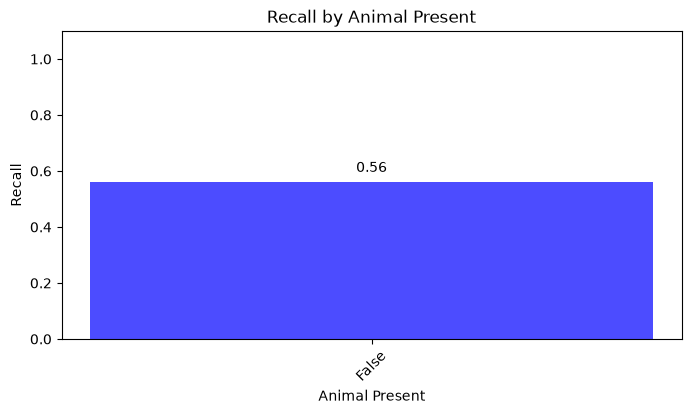

In [106]:
plot_single_bar_metric(animal_present_metrics, x_column='animal_present', metric='recall', title='Recall by Animal Present', ylabel='Recall', xlabel='Animal Present')


### Hit Rate


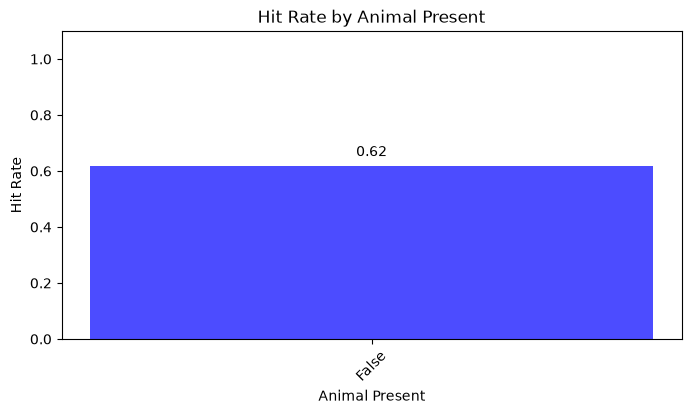

In [107]:
plot_single_bar_metric(animal_present_metrics, x_column='animal_present', metric='hit_rate', title='Hit Rate by Animal Present', ylabel='Hit Rate', xlabel='Animal Present')


### Diversity


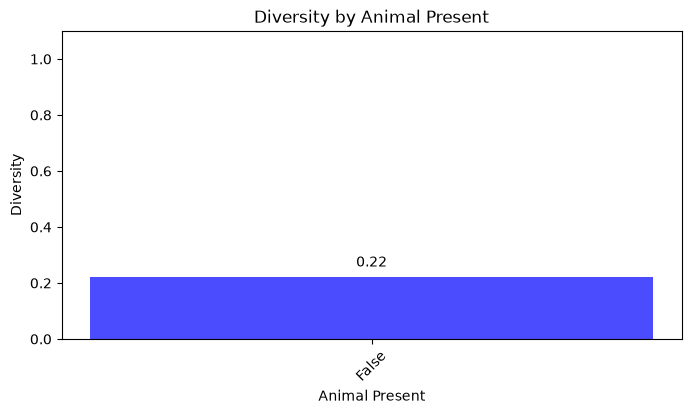

In [108]:
plot_single_bar_metric(animal_present_metrics, x_column='animal_present', metric='diversity', title='Diversity by Animal Present', ylabel='Diversity', xlabel='Animal Present')


### NDCG


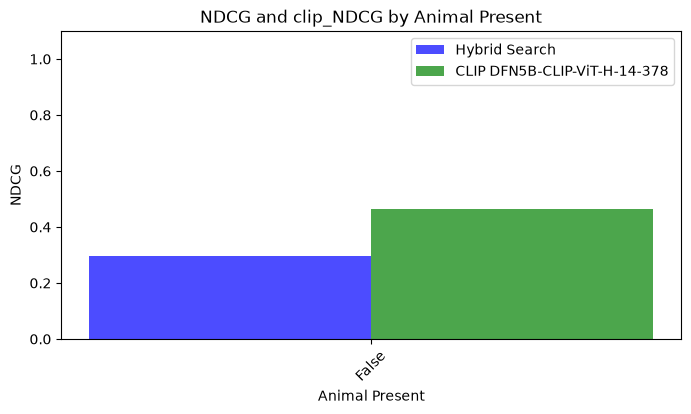

In [109]:
plot_rank_comparison(animal_present_metrics, x_column='animal_present', title='NDCG and clip_NDCG by Animal Present', xlabel='Animal Present')


### MRR


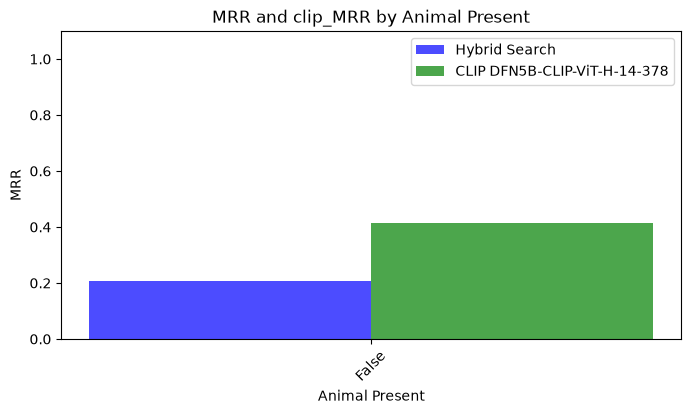

In [110]:
plot_rank_comparison(animal_present_metrics, x_column='animal_present', title='MRR and clip_MRR by Animal Present', xlabel='Animal Present', metric="MRR")


## Metrics based on Night Scene

Now, we will evaluate queries based on **Night Scene** (true vs false).


In [111]:
# Group by night_scene and calculate the sum/mean of each metric
night_scene_metrics = df.groupby('night_scene').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

night_scene_metrics['night_scene'] = night_scene_metrics['night_scene'].map({True: 'True', False: 'False'})

#rename columns
night_scene_metrics = night_scene_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
night_scene_metrics = night_scene_metrics.sort_values('night_scene')

night_scene_metrics


,night_scene,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,1975,72,1903,60,1915,0.036456,0.030380,0.618565,0.696203,0.352205,0.552093,0.254463,0.506450,0.212512
1,True,1025,31,994,19,1006,0.030244,0.018537,0.447154,0.463415,0.186689,0.292855,0.115105,0.237583,0.240974


### Accuracy


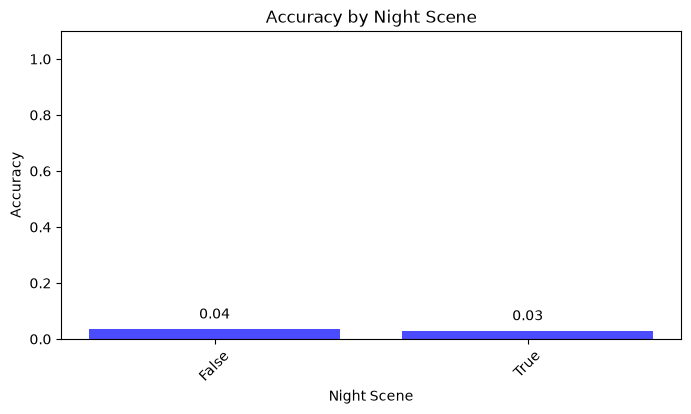

In [112]:
plot_single_bar_metric(night_scene_metrics, x_column='night_scene', metric='accuracy', title='Accuracy by Night Scene', ylabel='Accuracy', xlabel='Night Scene')


### Precision


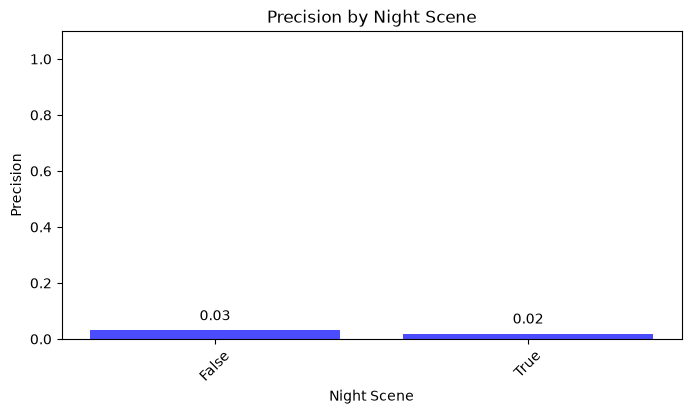

In [113]:
plot_single_bar_metric(night_scene_metrics, x_column='night_scene', metric='precision', title='Precision by Night Scene', ylabel='Precision', xlabel='Night Scene')


### Recall


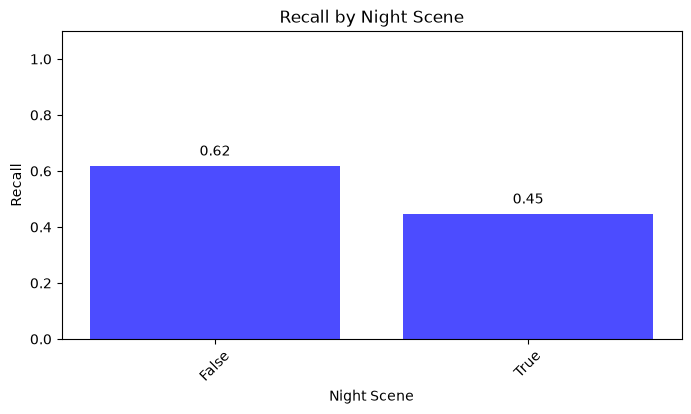

In [114]:
plot_single_bar_metric(night_scene_metrics, x_column='night_scene', metric='recall', title='Recall by Night Scene', ylabel='Recall', xlabel='Night Scene')


### Hit Rate


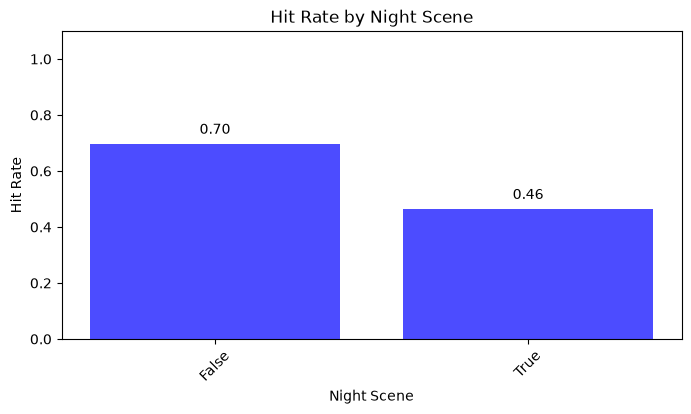

In [115]:
plot_single_bar_metric(night_scene_metrics, x_column='night_scene', metric='hit_rate', title='Hit Rate by Night Scene', ylabel='Hit Rate', xlabel='Night Scene')


### Diversity


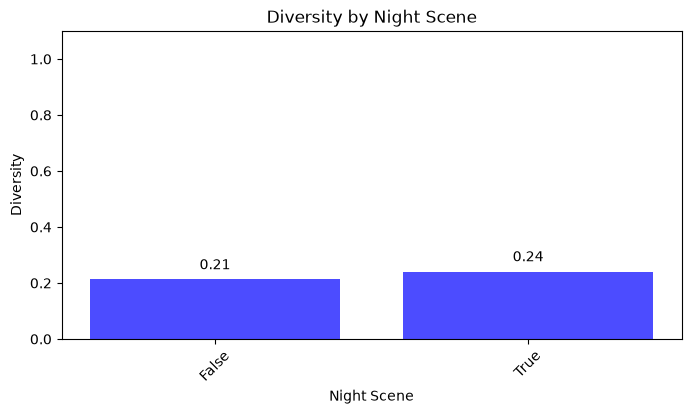

In [116]:
plot_single_bar_metric(night_scene_metrics, x_column='night_scene', metric='diversity', title='Diversity by Night Scene', ylabel='Diversity', xlabel='Night Scene')


### NDCG


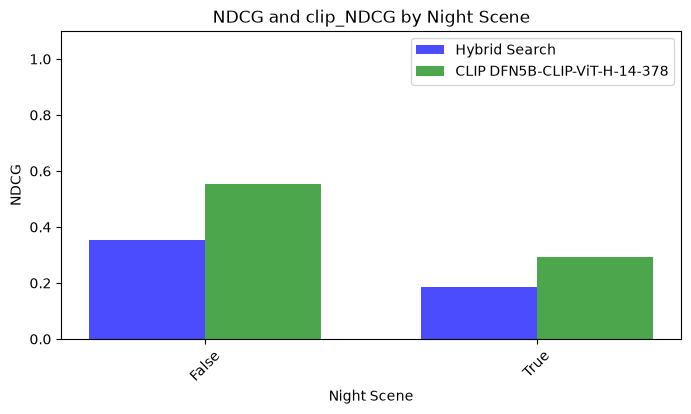

In [117]:
plot_rank_comparison(night_scene_metrics, x_column='night_scene', title='NDCG and clip_NDCG by Night Scene', xlabel='Night Scene')


### MRR


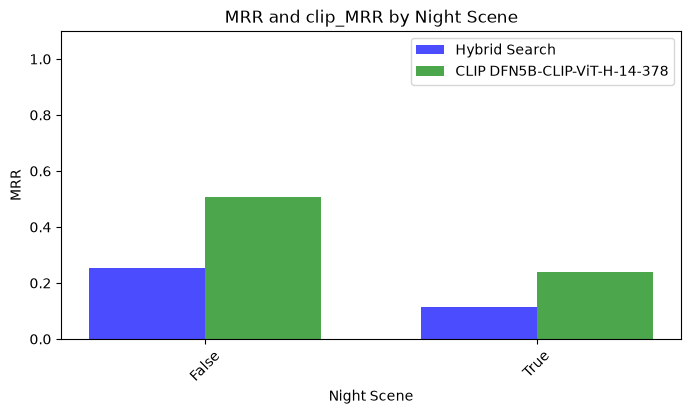

In [118]:
plot_rank_comparison(night_scene_metrics, x_column='night_scene', title='MRR and clip_MRR by Night Scene', xlabel='Night Scene', metric="MRR")


## Metrics based on Precipitation Visible

Now, we will evaluate queries based on **Precipitation Visible** (true vs false).


In [119]:
# Group by precipitation_visible and calculate the sum/mean of each metric
precipitation_visible_metrics = df.groupby('precipitation_visible').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

precipitation_visible_metrics['precipitation_visible'] = precipitation_visible_metrics['precipitation_visible'].map({True: 'True', False: 'False'})

#rename columns
precipitation_visible_metrics = precipitation_visible_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
precipitation_visible_metrics = precipitation_visible_metrics.sort_values('precipitation_visible')

precipitation_visible_metrics


,precipitation_visible,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,2900,101,2799,77,2823,0.034828,0.026552,0.562069,0.62069,0.300405,0.470352,0.211719,0.422418,0.223346
1,True,100,2,98,2,98,0.020000,0.020000,0.500000,0.50000,0.157876,0.265402,0.065625,0.187500,0.190063


### Accuracy


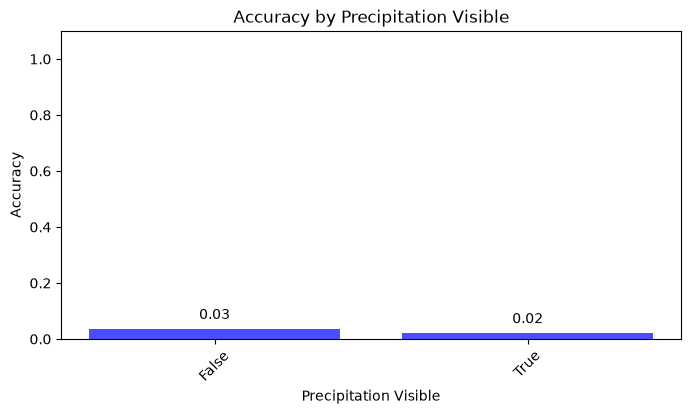

In [120]:
plot_single_bar_metric(precipitation_visible_metrics, x_column='precipitation_visible', metric='accuracy', title='Accuracy by Precipitation Visible', ylabel='Accuracy', xlabel='Precipitation Visible')


### Precision


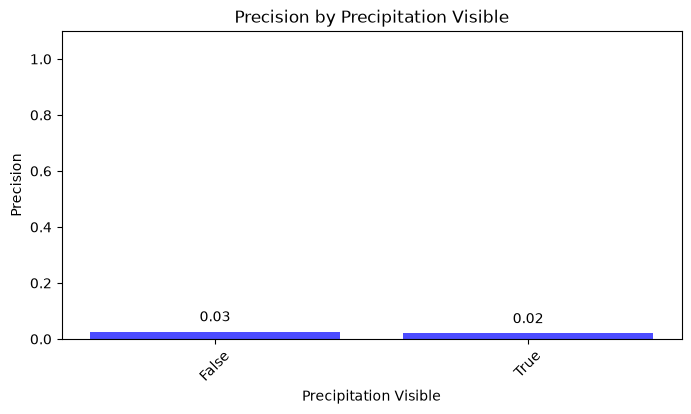

In [121]:
plot_single_bar_metric(precipitation_visible_metrics, x_column='precipitation_visible', metric='precision', title='Precision by Precipitation Visible', ylabel='Precision', xlabel='Precipitation Visible')


### Recall


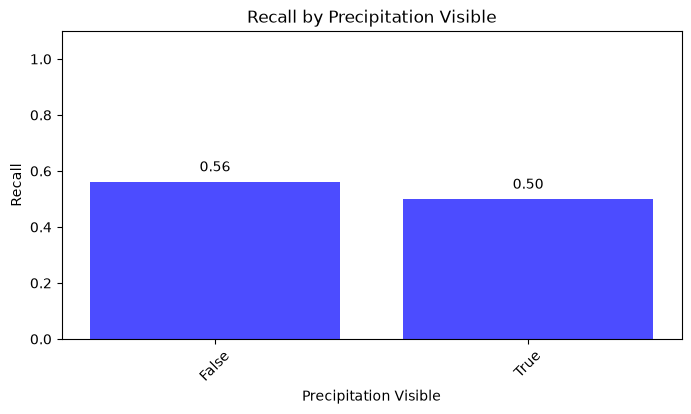

In [122]:
plot_single_bar_metric(precipitation_visible_metrics, x_column='precipitation_visible', metric='recall', title='Recall by Precipitation Visible', ylabel='Recall', xlabel='Precipitation Visible')


### Hit Rate


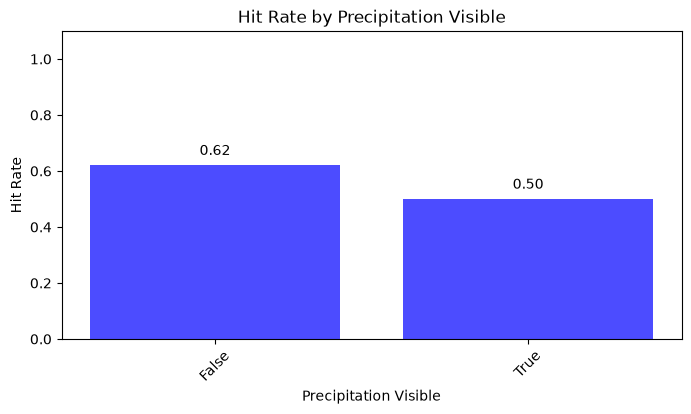

In [123]:
plot_single_bar_metric(precipitation_visible_metrics, x_column='precipitation_visible', metric='hit_rate', title='Hit Rate by Precipitation Visible', ylabel='Hit Rate', xlabel='Precipitation Visible')


### Diversity


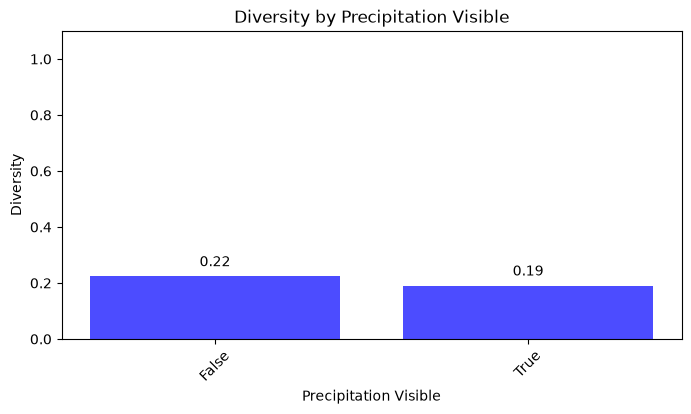

In [124]:
plot_single_bar_metric(precipitation_visible_metrics, x_column='precipitation_visible', metric='diversity', title='Diversity by Precipitation Visible', ylabel='Diversity', xlabel='Precipitation Visible')


### NDCG


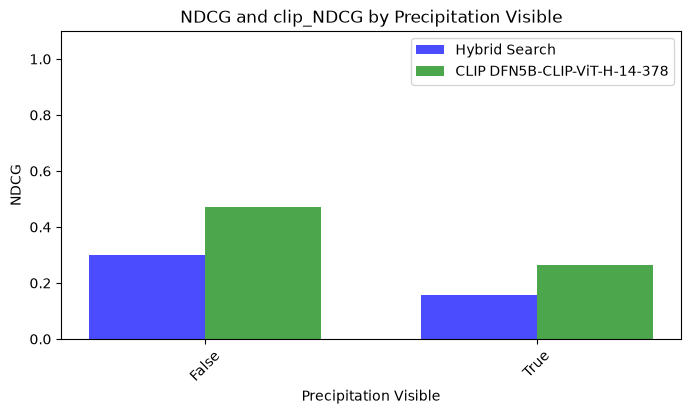

In [125]:
plot_rank_comparison(precipitation_visible_metrics, x_column='precipitation_visible', title='NDCG and clip_NDCG by Precipitation Visible', xlabel='Precipitation Visible')


### MRR


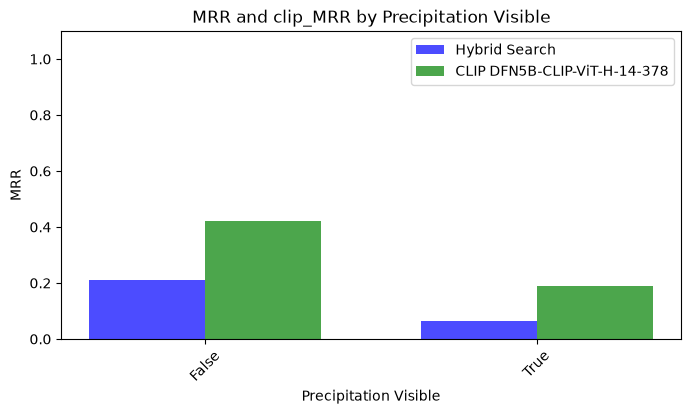

In [126]:
plot_rank_comparison(precipitation_visible_metrics, x_column='precipitation_visible', title='MRR and clip_MRR by Precipitation Visible', xlabel='Precipitation Visible', metric="MRR")


## Metrics based on Multiple Objects

Now, we will evaluate queries based on **Multiple Objects** (true vs false).


In [127]:
# Group by multiple_objects and calculate the sum/mean of each metric
multiple_objects_metrics = df.groupby('multiple_objects').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

multiple_objects_metrics['multiple_objects'] = multiple_objects_metrics['multiple_objects'].map({True: 'True', False: 'False'})

#rename columns
multiple_objects_metrics = multiple_objects_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})
multiple_objects_metrics = multiple_objects_metrics.sort_values('multiple_objects')

multiple_objects_metrics


,multiple_objects,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,250,7,243,5,245,0.028000,0.020000,0.500000,0.500000,0.129944,0.290987,0.037666,0.225758,0.307869
1,True,2750,96,2654,74,2676,0.034909,0.026909,0.565455,0.627273,0.310718,0.479205,0.222229,0.431753,0.214452


### Accuracy


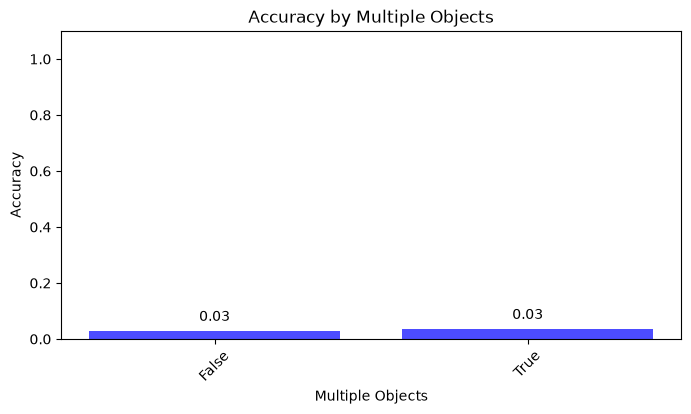

In [128]:
plot_single_bar_metric(multiple_objects_metrics, x_column='multiple_objects', metric='accuracy', title='Accuracy by Multiple Objects', ylabel='Accuracy', xlabel='Multiple Objects')


### Precision


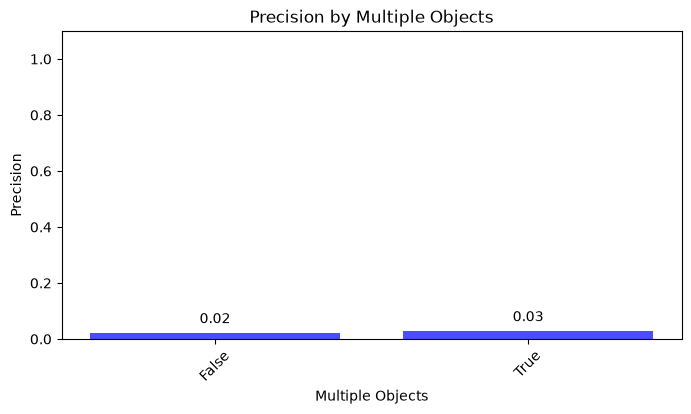

In [129]:
plot_single_bar_metric(multiple_objects_metrics, x_column='multiple_objects', metric='precision', title='Precision by Multiple Objects', ylabel='Precision', xlabel='Multiple Objects')


### Recall


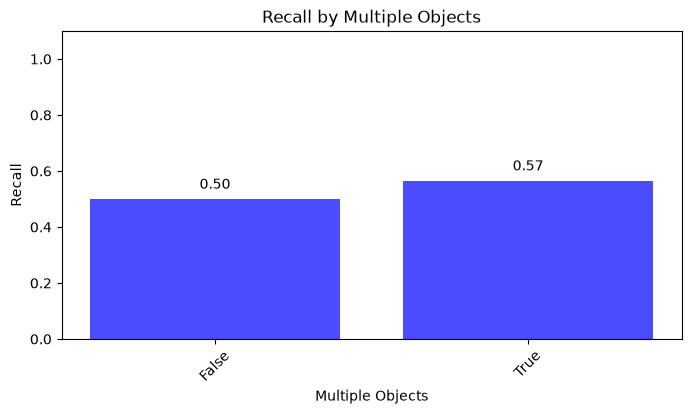

In [130]:
plot_single_bar_metric(multiple_objects_metrics, x_column='multiple_objects', metric='recall', title='Recall by Multiple Objects', ylabel='Recall', xlabel='Multiple Objects')


### Hit Rate


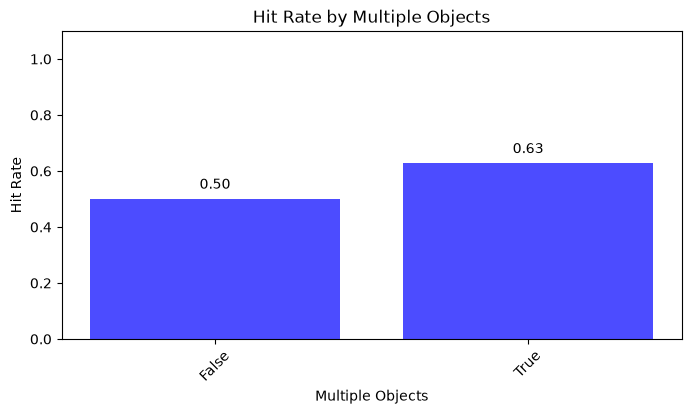

In [131]:
plot_single_bar_metric(multiple_objects_metrics, x_column='multiple_objects', metric='hit_rate', title='Hit Rate by Multiple Objects', ylabel='Hit Rate', xlabel='Multiple Objects')


### Diversity


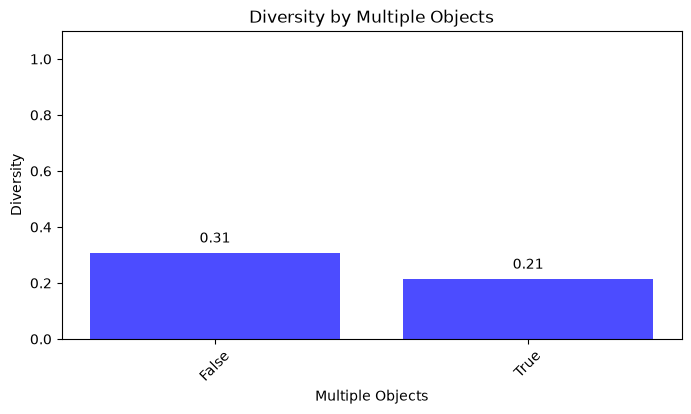

In [132]:
plot_single_bar_metric(multiple_objects_metrics, x_column='multiple_objects', metric='diversity', title='Diversity by Multiple Objects', ylabel='Diversity', xlabel='Multiple Objects')


### NDCG


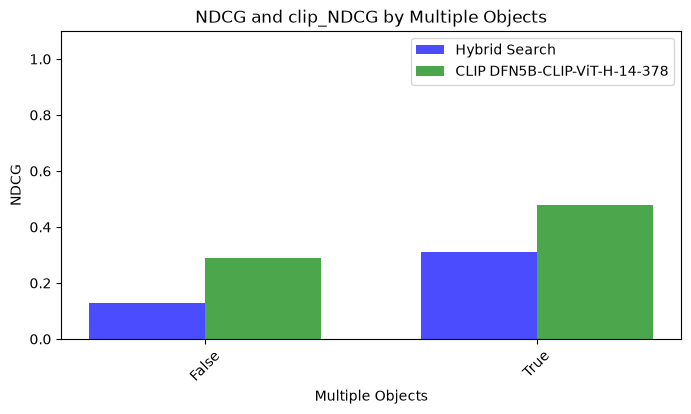

In [133]:
plot_rank_comparison(multiple_objects_metrics, x_column='multiple_objects', title='NDCG and clip_NDCG by Multiple Objects', xlabel='Multiple Objects')


### MRR


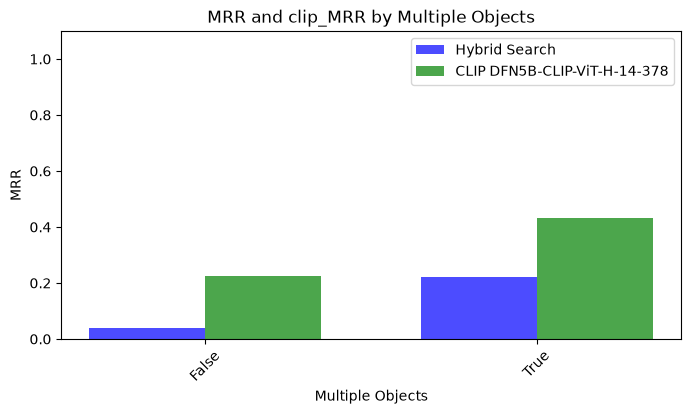

In [134]:
plot_rank_comparison(multiple_objects_metrics, x_column='multiple_objects', title='MRR and clip_MRR by Multiple Objects', xlabel='Multiple Objects', metric="MRR")


## Metrics based on Viewpoint & Precipitation Visible

Here we will group by Precipitation Visible and Viewpoint and calculate the sum/mean of each metric to see how the system performs under different Precipitation Visible and Viewpoint conditions.

>NOTE: due to the large number of combinations you can group by, we will not show all of them. Use this section as a guide if you want to break down the data by different combinations of the metadata.

In [135]:
# Group
view_preci_metrics = df.groupby(['viewpoint', 'precipitation_visible']).agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()
view_preci_metrics['precipitation_visible'] = view_preci_metrics['precipitation_visible'].map({True: 'True', False: 'False'})

#rename columns
view_preci_metrics = view_preci_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

# set up graph variables
metrics = view_preci_metrics
x_column = 'viewpoint'
group_column = 'precipitation_visible'
title = 'Viewpoint & Precipitation Visible'
colors = {
    "True": "green",
    "False": "red",
}

metrics

,viewpoint,precipitation_visible,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,duo_view,False,50,1,49,0,50,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.202919
1,fisheye_sky,False,625,21,604,16,609,0.033600,0.025600,0.480000,0.560000,0.253881,0.449727,0.165333,0.416667,0.222849
2,fisheye_sky,True,75,1,74,1,74,0.013333,0.013333,0.333333,0.333333,0.128951,0.143559,0.066667,0.083333,0.165524
3,ground_horizontal,False,1900,67,1833,52,1848,0.035263,0.027368,0.605702,0.657895,0.316414,0.488761,0.227035,0.434117,0.221755
4,ground_horizontal,True,25,1,24,1,24,0.040000,0.040000,1.000000,1.000000,0.244651,0.630930,0.062500,0.500000,0.263682
5,ground_upward,False,150,6,144,3,147,0.040000,0.020000,0.500000,0.500000,0.350755,0.315465,0.266667,0.250000,0.311334
6,oblique,False,125,5,120,5,120,0.040000,0.040000,0.633333,0.800000,0.423678,0.800000,0.304286,0.800000,0.116795
7,unknown,False,50,1,49,1,49,0.020000,0.020000,0.500000,0.500000,0.114762,0.139471,0.025000,0.045455,0.312851


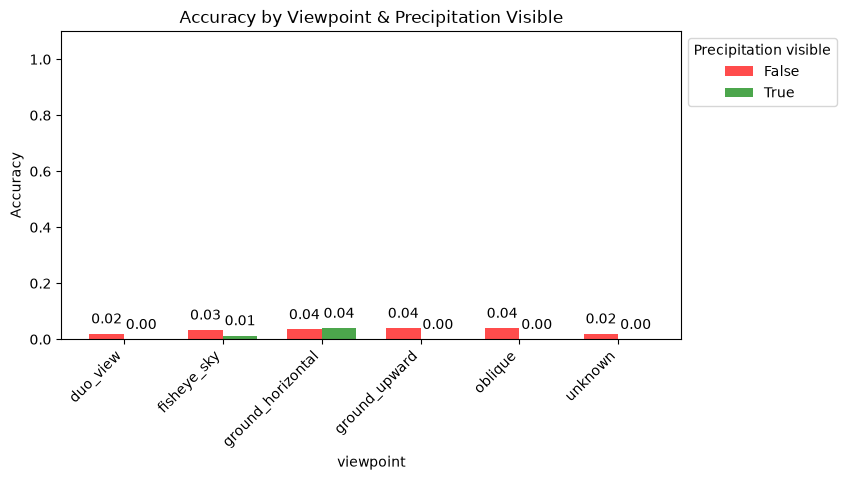

In [136]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='accuracy', 
    color_map=colors, 
    ylabel="Accuracy", 
    xlabel=x_column, 
    title=f"Accuracy by {title}",
)

### Precision

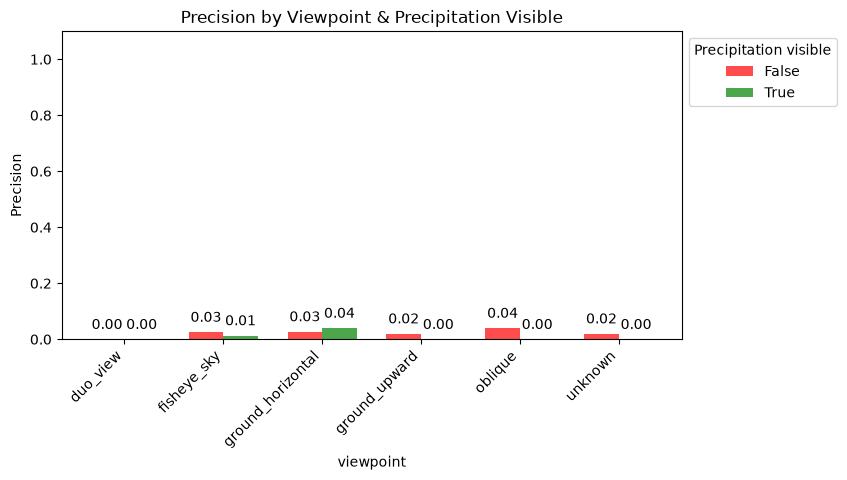

In [137]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='precision', 
    color_map=colors, 
    ylabel="Precision", 
    xlabel=x_column, 
    title=f"Precision by {title}",
)

### Recall

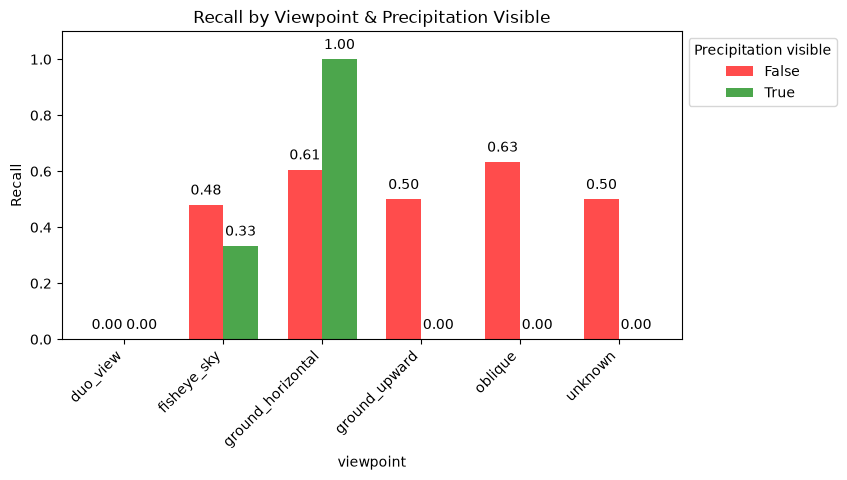

In [138]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='recall', 
    color_map=colors,
    ylabel="Recall", 
    xlabel=x_column, 
    title=f"Recall by {title}",
)


### Hit Rate

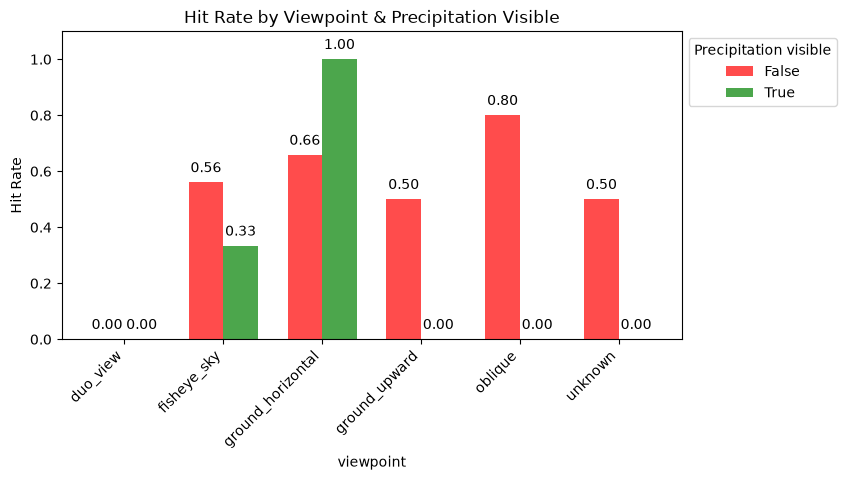

In [139]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='hit_rate', 
    color_map=colors,
    ylabel="Hit Rate", 
    xlabel=x_column, 
    title=f"Hit Rate by {title}",
)

### Diversity

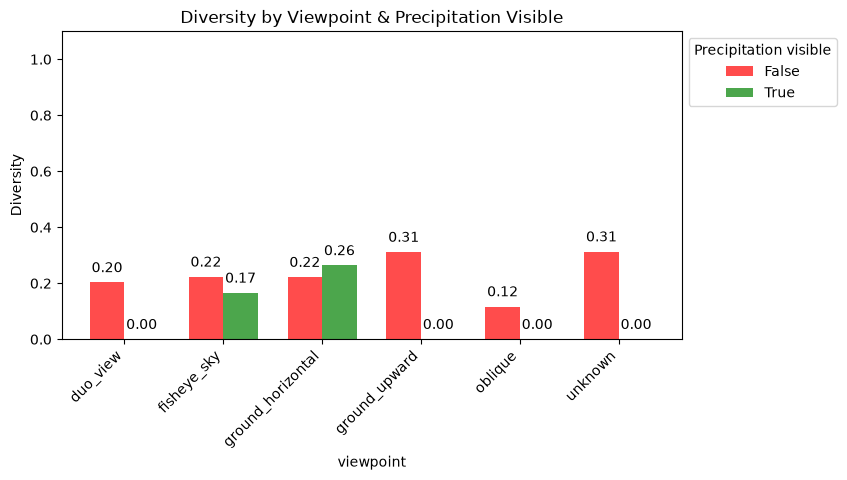

In [140]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='diversity', 
    color_map=colors,
    ylabel="Diversity", 
    xlabel=x_column, 
    title=f"Diversity by {title}",
)

### NDCG

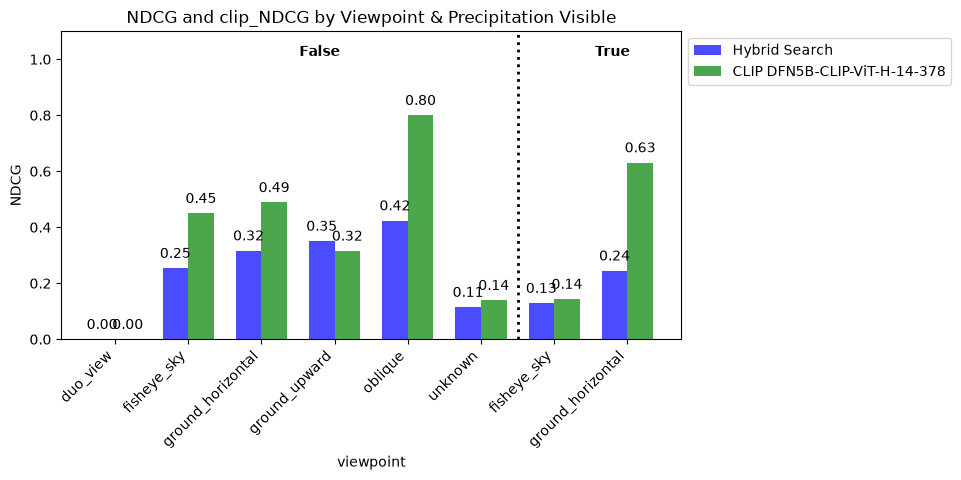

In [141]:
# Sort by group_column so group dividers and labels are correct
_ndcg_df = metrics.sort_values(group_column).reset_index(drop=True)
plot_multi_rank_comparison(
    _ndcg_df,
    x_column=x_column,
    group_column=group_column,
    title=f"NDCG and clip_NDCG by {title}",
    xlabel=x_column,
)


### MRR

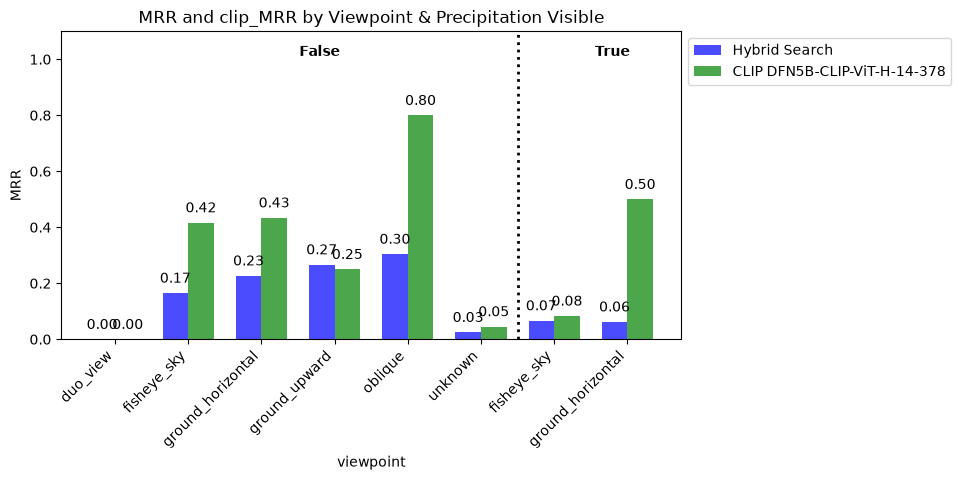

In [142]:
_mrr_df = metrics.sort_values(group_column).reset_index(drop=True)
plot_multi_rank_comparison(_mrr_df, x_column=x_column, group_column=group_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")

## Insights & Conclusion

**System Difference**

* **v12:** Weaviate hybrid search over **one fused CLIP index** (caption + image embeddings combined into a single `clip` vector), with the Weaviate / [ms-marco-MiniLM-L6-v2](https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2) reranker. Keyword search used named Sage fields (`caption`, `vsn`, `zone`, `host`, `job`, `camera`, …). CLIP inference had **no Triton dynamic batching**.
* **v13:**
  * **Weaviate → Milvus** as the vector database.
  * **Weaviate reranker → Apple CLIP DFN** (`DFN5B-CLIP-ViT-H-14-378`): query text vs stored `image_vector`s.
  * **One fused index → dual indexing**: separate `caption_vector` and `image_vector` fields, blended at query time (`clip_alpha=0.7`).
  * **Keyword search → Milvus BM25** over `search_text` (instead of per-field Weaviate properties).
  * **No Triton batching → Triton dynamic batching** for CLIP (and Gemma when served on Triton), so concurrent embedding/caption requests coalesce into larger GPU batches.

---

**Overall Metrics Comparison**

| Metric                   | v12 | v13 | Difference (v13 - v12) |
| ------------------------ | --- | --- | ----------------------- |
| **Total Images**         | 3,000 | 3,000 | 0 |
| **Correctly Returned**   | 79 | 103 | +24 |
| **Incorrectly Returned** | 2,921 | 2,897 | −24 |
| **Relevant Images**      | 68 | 79 | +11 |
| **Non-Relevant Images**  | 2,932 | 2,921 | −11 |
| **Accuracy**             | 0.0263 | 0.0343 | +0.0080 |
| **Precision**            | 0.0227 | 0.0263 | +0.0036 |
| **Recall**               | 0.5033 | 0.5600 | +0.0567 |
| **Hit Rate**             | 0.5417 | 0.6167 | +0.0750 |
| **Diversity**            | 0.2070 | 0.2222 | +0.0152 |
| **NDCG** | 0.2111 | 0.2957 | +0.0845 |
| **clip_NDCG** | 0.4274 | 0.4635 | +0.0361 |
| **MRR** | 0.1218 | 0.2068 | +0.0851 |
| **clip_MRR** | 0.3915 | 0.4146 | +0.0231 |

---

**Interpretation**

**v13 (Milvus dual-index + CLIP DFN rerank)** improves **every reported metric** versus **v12** on Sagebench. With the same **3,000** returned images (120 queries × top‑25), **correctly returned** (+24), **relevant images** (+11), **accuracy**, **precision**, **recall**, and **hit rate** (+7.5 pp; 65/120 → 74/120) all rise. **Diversity** ticks up as well (+0.015).

**Ranking improves in lockstep with the CLIP oracle, not past it.** **NDCG** and **MRR** each gain ~0.08, and **clip_NDCG / clip_MRR** rise by about the same amount — so the top‑25 lists contain better CLIP-aligned content. The **gap to the CLIP oracle stays large** (NDCG **0.30 vs 0.46**; MRR **0.21 vs 0.41**), similar to v12's gap. CLIP DFN ranks the returned lists better than MiniLM did, but still short of CLIP-as-oracle order. Sage queries mix **visual content with node metadata** (vsn, zone, job, camera); labeled relevance is often “this node's image,” which image-vector cosine does not encode.

---

**Insights**

- **Hit churn favors v13:** 23 queries gained a hit, 14 lost one, 51 stayed hits. Gains include forest/tower platforms, mobotix split visible/thermal, night IR, and several **fisheye top-camera** sky views. Losses are mixed night silhouettes and some shield-zone fisheye/sun queries.
- **Daytime and core nodes improved; night and shield did not.** Day hit rate **0.57 → 0.68**; night stays **0.46** (MRR slightly down). **core** zone hit rate **0.45 → 0.61**; **shield** **0.73 → 0.57**. v12's per-field BM25 on `zone` / `vsn` / `job` likely helped shield queries more than a single `search_text` BM25 field.
- **CLIP image rerank helps visual scenes, not metadata constraints.** Mixed/vegetation/rural and ground-horizontal views move up; ground-dominant and some night node-ID queries do not. That matches Firebench/INQUIRE (visual CLIP rerank helps) more than Cloudbench, but Sagebench's remaining MRR hole is the metadata half of the query.
- **Caption DLQ is large.** 896 rows, all **force-inserted** with dataset-summary fallback (0 recovered, 0 abandoned). Degraded captions weaken `caption_vector` and BM25; the **image_vector** path still produced the retrieval gain. Fixing caption yield would matter more here than on Firebench because Sage keyword search is supposed to carry vsn/job/camera tokens.
- **v13 also beats the prior image-only ablation** on hit rate (0.55 → 0.62) and relevant counts (75 → 79), with similar MRR (ablation 0.157 vs v13 0.207). Dual-index hybrid is no longer a regression vs image-only on this bench; the leftover problem is **first-hit ranking of node-specific hits**, not candidate generation.
- Several stack changes landed together; Triton batching does not change ranking. Quality shifts should be read as a **bundle**.

---

**Conclusion**

On Sagebench, **v13 is a clear improvement over v12** on retrieval (accuracy, precision, recall, hit rate, relevant counts) and on **NDCG / MRR**, with a small diversity gain. The production Milvus dual-index + CLIP DFN stack retrieves more of the right edge-node images. **First-hit ranking remains far behind the CLIP oracle** because queries are metadata-heavy and CLIP image rerank cannot prefer a specific VSN. Next gains are more likely from **putting Sage fields into BM25/`search_text` (or a structured filter)** and **raising caption yield** than from another database or CLIP swap.


